## Описание проекта

**Заголовок:** Определение стоимости автомобилей для сервиса "Не бит, не крашен".

**Описание проекта:** Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение, чтобы привлечь новых клиентов. В нём можно будет узнать рыночную стоимость своего автомобиля. Необходимо построить модель, которая умеет её определять. В нашем распоряжении данные о технических характеристиках, комплектации и ценах других автомобилей.

Критерии, которые важны заказчику:  
- качество предсказания
- время обучения модели
- время предсказания модели

**Цель проекта:**  Создать модель определения рыночной стоимости автомобилей для приложения, с целью привлечения новых клиентов

**Ход проекта:** 
- Описание данных предоставленные "Не бит, не крашен"
    - Подготовка данных: загрузка, описание, анализ общей информации из датасетов "Не бит, не крашен"
    - Предобработка данных: пропуски, дубликаты, типы данных
    - Исследовательский анализ данных, поиск аномалий
    - Подготовка данных для машинного обучения
    - Обучение моделей
    - Анализ времени обучения, времени предсказания и качества моделей
    - Определение качества на тестовой выборке
    - Выводы


**Общий вывод:** резюмирование полученных результатов, формулировка ключевых выводов и рекомендаций бизнесу

С помощью данного исследования мы стремимся:
- разработать инструмент определения стоимости автомобилей, с последующим внедрением в приложение компании, с целью привлечения новых покупателей. 

### Описание данных

Данные находятся в файле `autos.csv`  

**Признаки**

`DateCrawled` — дата скачивания анкеты из базы  
`VehicleType` — тип автомобильного кузова  
`RegistrationYear` — год регистрации автомобиля  
`Gearbox` — тип коробки передач  
`Power` — мощность (л. с.)  
`Model` — модель автомобиля  
`Kilometer` — пробег (км)  
`RegistrationMonth` — месяц регистрации автомобиля  
`FuelType` — тип топлива  
`Brand` — марка автомобиля  
`Repaired` — была машина в ремонте или нет  
`DateCreated` — дата создания анкеты  
`NumberOfPictures` — количество фотографий автомобиля  
`PostalCode` — почтовый индекс владельца анкеты (пользователя)  
`LastSeen` — дата последней активности пользователя  

**Целевой признак**  
`Price` — цена (евро)  

### Импорты библиотек

In [1]:
!pip install scikit-learn==1.4.2 -q
!pip install catboost -q
!pip install lightgbm -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import math
import numpy as np
import time

import warnings

In [3]:
from phik import phik_matrix
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)
from sklearn.tree import DecisionTreeRegressor

In [4]:
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

In [5]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
UNKNOWN_CATEGORY = -1

## Загрузка данных

In [6]:
#Функция для импорта в df и проверка
def import_info_data(way, sep=',', decimal='.'):
    
    try:
        data = pd.read_csv('/datasets/' + way, sep=sep, decimal=decimal)
    except FileNotFoundError:
        data = pd.read_csv(way, sep=sep)
    display(data.head(5))
    display(data.info()) 
    print(f'Количество дубликатов: {data.duplicated().sum()}')
    print(f'Количество пропусков: {data.isna().sum()}')
    display(data.describe()) 
    print(f'''Размер датафрейма: {data.shape}''')
    return data

### Общие сведения датасета

In [7]:
autos_data = import_info_data('autos.csv')

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

None

Количество дубликатов: 4
Количество пропусков: DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64


,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


Размер датафрейма: (354369, 16)


### Выводы

Датафрейм загрузился без проблем. 

Столбцы совпадают с описанием.  
Явные пропуски в 5-ти стобцах: VehicleType, Gearbox, Model, FuelType, Repaired  
Явных дубликатов 4, однако будем еще проверять на неявные.  
Тип колонок с датами необходимо перевести в формат дат.  

**Среди признаков есть очевидно неинформативные:**  
`DateCrawled` — дата скачивания анкеты это случайный момент времени, не влияющий на стоимость.  
`NumberOfPictures` — количество фотографий. Хотя может косвенно говорить о старательности продавца, это мета-информация об объявлении, а не о самом автомобиле. Да и там нули сплошные.  
`PostalCode` — почтовый индекс владельца. Сам по себе не влияет на стоимость машины. Однако! Из него можно извлечь полезный признак — регион, который уже может влиять на цену из-за разного спроса и предложения. Но "сырой" почтовый индекс как номер — шум. Проверим.  
`LastSeen` — дата последней активности пользователя. Скорее указывает на время удаления объявления, не несёт информации о цене автомобиля.  
`DateCreated` — дата создания анкеты. Аналогично — момент размещения объявления, а не характеристика авто
`RegistrationMonth` — месяц регистрации. Практически никогда не влияет на стоимость. Исключение — редкие случаи, связанные с модельными годами, но это крайне слабый признак.

**Аномалии в данных:**  
`Price`: цена "0"  
`RegistrationYear`: год регистрации "1000" и "9999"  
`Power`: мощность "0" и "20000"  
`RegistrationMonth`: месяцы начинаются с "0"  


Общая информация о датасетах предопределила последующие шаги в предобработке:

- поиск и обработка неявных дублей
- поиск и обработка пропусков
- корректировка типов данных с датами
- EDA и удаление неинформативных признаков


## Предобработка данных

### Удаление неинформативных признаков

In [8]:
autos_data['DateCrawled'].max()

'2016-04-07 14:36:58'

In [9]:
uninformative_feature = ['DateCrawled', 'RegistrationMonth', 'DateCreated', 'NumberOfPictures', 'LastSeen', 'PostalCode']

In [10]:
autos_data[uninformative_feature]

,DateCrawled,RegistrationMonth,DateCreated,NumberOfPictures,LastSeen,PostalCode
0,2016-03-24 11:52:17,0,2016-03-24 00:00:00,0,2016-04-07 03:16:57,70435
1,2016-03-24 10:58:45,5,2016-03-24 00:00:00,0,2016-04-07 01:46:50,66954
2,2016-03-14 12:52:21,8,2016-03-14 00:00:00,0,2016-04-05 12:47:46,90480
3,2016-03-17 16:54:04,6,2016-03-17 00:00:00,0,2016-03-17 17:40:17,91074
4,2016-03-31 17:25:20,7,2016-03-31 00:00:00,0,2016-04-06 10:17:21,60437
...,...,...,...,...,...,...
354364,2016-03-21 09:50:58,7,2016-03-21 00:00:00,0,2016-03-21 10:42:49,2694
354365,2016-03-14 17:48:27,1,2016-03-14 00:00:00,0,2016-04-06 00:46:52,39576
354366,2016-03-05 19:56:21,3,2016-03-05 00:00:00,0,2016-03-11 18:17:12,26135
354367,2016-03-19 18:57:12,3,2016-03-19 00:00:00,0,2016-04-07 07:15:26,87439


Как и предполагалось, эти признаки не несут никакой информации, фотографии вообще нули, а из почтового кода никак не выделить страну. Хотя надежда имелась. Дропаем

In [11]:
autos_data.drop(uninformative_feature, axis=1, inplace=True)

### Обработка аномальных значений

In [12]:
length_data = len(autos_data)
length_data

354369

##### Price - целевой признак

In [13]:
autos_data[autos_data['Price'] == 0]

,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,FuelType,Brand,Repaired
7,0,sedan,1980,manual,50,other,40000,petrol,volkswagen,no
40,0,NaN,1990,NaN,0,corsa,150000,petrol,opel,NaN
111,0,NaN,2017,manual,0,golf,5000,petrol,volkswagen,NaN
115,0,small,1999,NaN,0,NaN,5000,petrol,volkswagen,NaN
152,0,bus,2004,manual,101,meriva,150000,lpg,opel,yes
...,...,...,...,...,...,...,...,...,...,...
354205,0,NaN,2000,manual,65,corsa,150000,NaN,opel,yes
354238,0,small,2002,manual,60,fiesta,150000,petrol,ford,NaN
354248,0,small,1999,manual,53,swift,150000,petrol,suzuki,NaN
354277,0,small,1999,manual,37,arosa,150000,petrol,seat,yes


In [14]:
print(f" Данных с нулевым значением 'price' в исходной таблице {(autos_data[autos_data['Price'] == 0].shape[0] / autos_data.shape[0]):.2%}")

 Данных с нулевым значением 'price' в исходной таблице 3.04%


Для модели важна точность. Заполнение средним или медианой может исказить данные. И их достаточно мало, всего 3%. Удалим эти аномалии.

In [15]:
autos_data = autos_data[autos_data['Price'] > 0]

##### RegistrationYear

In [16]:
autos_data[(autos_data['RegistrationYear'] <= 1960) | (autos_data['RegistrationYear'] > 2016)].head()


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,FuelType,Brand,Repaired
15,450,small,1910,NaN,0,ka,5000,petrol,ford,NaN
22,2900,NaN,2018,manual,90,meriva,150000,petrol,opel,no
26,5555,NaN,2017,manual,125,c4,125000,NaN,citroen,no
48,7750,NaN,2017,manual,80,golf,100000,petrol,volkswagen,NaN
51,2000,NaN,2017,manual,90,punto,150000,gasoline,fiat,yes


In [17]:
print(f'''Аномальных данных в'RegistrationYear' {(autos_data[(autos_data['RegistrationYear'] <= 1960) | (autos_data['RegistrationYear'] > 2016)].shape[0] / autos_data.shape[0]):.2%}''')



Аномальных данных в'RegistrationYear' 4.15%


Данных также достаточно мало, можем этими данными пренебречь.

In [18]:
autos_data = autos_data[(autos_data['RegistrationYear'] >= 1960) & (autos_data['RegistrationYear'] < 2016)]

In [19]:
autos_data['FuelType'].unique()

array(['petrol', 'gasoline', nan, 'lpg', 'other', 'hybrid', 'cng',
       'electric'], dtype=object)

In [20]:
autos_data['FuelType'] = autos_data['FuelType'].replace({'gasoline': 'petrol'})
autos_data['FuelType'].unique()

array(['petrol', nan, 'lpg', 'other', 'hybrid', 'cng', 'electric'],
      dtype=object)

##### Power

In [21]:
np.unique(autos_data['Power'])

array([    0,     1,     2,     3,     4,     5,     6,     7,     8,
           9,    10,    11,    12,    13,    14,    15,    16,    17,
          18,    19,    20,    21,    22,    23,    24,    25,    26,
          27,    28,    29,    30,    31,    32,    33,    34,    35,
          36,    37,    38,    39,    40,    41,    42,    43,    44,
          45,    46,    47,    48,    49,    50,    51,    52,    53,
          54,    55,    56,    57,    58,    59,    60,    61,    62,
          63,    64,    65,    66,    67,    68,    69,    70,    71,
          72,    73,    74,    75,    76,    77,    78,    79,    80,
          81,    82,    83,    84,    85,    86,    87,    88,    89,
          90,    91,    92,    93,    94,    95,    96,    97,    98,
          99,   100,   101,   102,   103,   104,   105,   106,   107,
         108,   109,   110,   111,   112,   113,   114,   115,   116,
         117,   118,   119,   120,   121,   122,   123,   124,   125,
         126,   127,

In [22]:
print(f" Аномальных данных в 'Power' {(autos_data[(autos_data['Power'] > 500) | (autos_data['Power'] < 40)].shape[0] / autos_data.shape[0]):.2%}")

 Аномальных данных в 'Power' 9.91%


Достаточно много. Заполним медианным значением

In [23]:
autos_data.loc[(autos_data['Power'] < 40) | (autos_data['Power'] > 500), 'Power'] = autos_data['Power'].median()


### Обработка пропусков

In [24]:
def percentage_of_omissions(data):
    (
        (data.isna().mean()*100)
        .to_frame()
        .rename(columns = {0:'space'})
        .query('space > 0')
        .sort_values(by = 'space', ascending = True)
        .plot(kind = 'barh', figsize = (18,8), legend = False, fontsize = 16)
        .set_title('% пропусков в данных', fontsize = 22, color = 'SteelBlue')
    )
    plt.show()

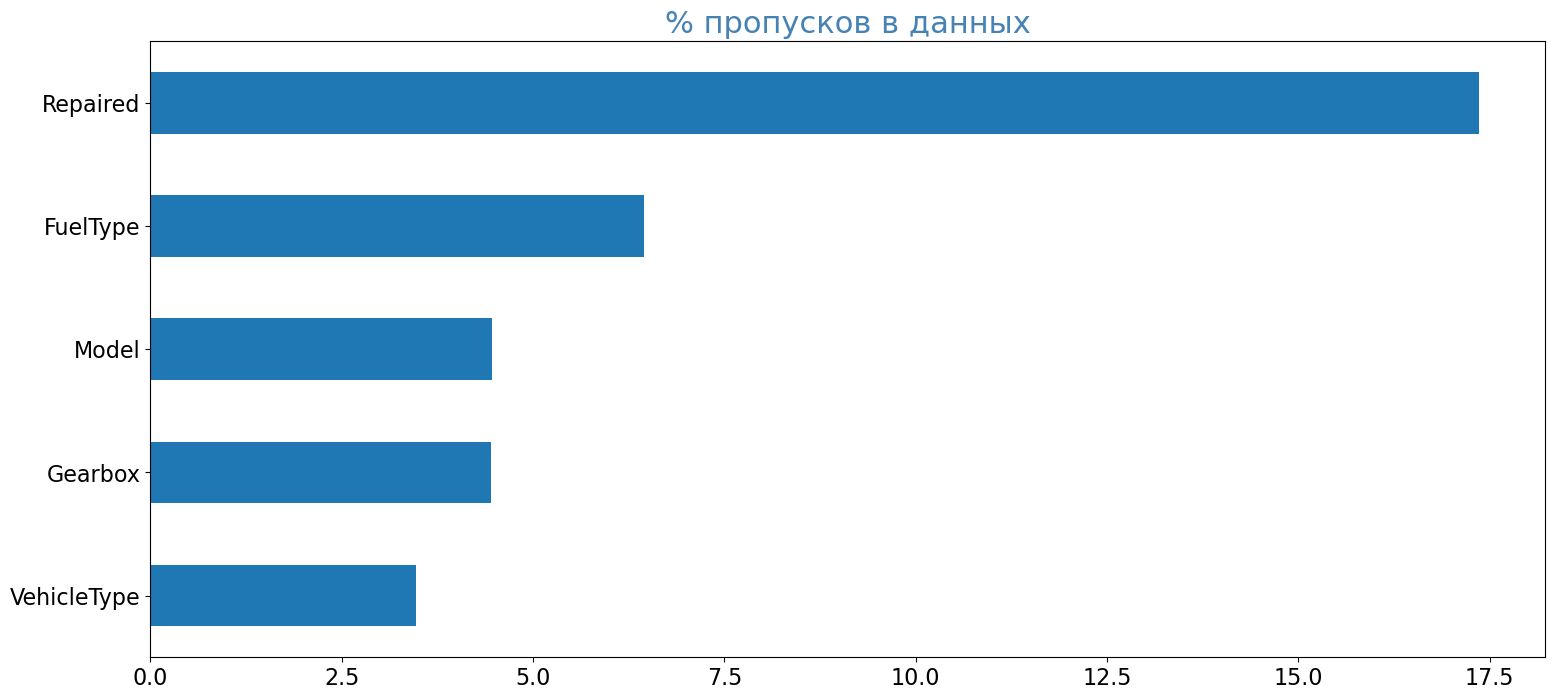

In [25]:
percentage_of_omissions(autos_data)

In [26]:
def unique (data):  
    for column in data.columns[data.dtypes=='object']:
        print(f'''Количество уникальных значений в столбце `{column}`: {data[column].nunique()}''')
        print(data[column].unique())
    return

In [27]:
unique(autos_data)

Количество уникальных значений в столбце `VehicleType`: 8
[nan 'coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon' 'other']
Количество уникальных значений в столбце `Gearbox`: 2
['manual' 'auto' nan]
Количество уникальных значений в столбце `Model`: 250
['golf' nan 'grand' 'fabia' '3er' '2_reihe' 'c_max' '3_reihe' 'passat'
 'navara' 'twingo' 'a_klasse' 'scirocco' '5er' 'arosa' 'other' 'civic'
 'transporter' 'punto' 'e_klasse' 'kadett' 'one' 'fortwo' 'clio' '1er'
 'b_klasse' 'signum' 'astra' 'a8' 'jetta' 'polo' 'fiesta' 'c_klasse'
 'micra' 'vito' 'sprinter' '156' 'escort' 'forester' 'xc_reihe' 'scenic'
 'a4' 'ka' 'a1' 'insignia' 'combo' 'focus' 'tt' 'corsa' 'a6' 'jazz'
 'omega' 'slk' '7er' '80' '147' '100' 'z_reihe' 'sorento' 'v40' 'ibiza'
 'mustang' 'eos' 'touran' 'getz' 'a3' 'megane' 'lupo' 'r19' 'caddy'
 'mondeo' 'cordoba' 'colt' 'impreza' 'vectra' 'berlingo' 'tiguan' 'sharan'
 '6_reihe' 'c4' 'panda' 'up' 'i_reihe' 'ceed' 'kangoo' '5_reihe' 'yeti'
 'octavia' 'zafira' 'mii' 'rx_

In [28]:
autos_data.isna().sum()


Price                   0
VehicleType         11105
RegistrationYear        0
Gearbox             14283
Power                   0
Model               14312
Kilometer               0
FuelType            20684
Brand                   0
Repaired            55638
dtype: int64

In [29]:
autos_data.fillna({'Gearbox':'manual', 'Repaired':'no', 'Model':'unknown'},  inplace=True)

VehicleType

In [30]:
# заменим пропущенные значения самым популярным по группе
autos_data['VehicleType'] = autos_data.groupby('Brand')['VehicleType'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'unknown') 
    if x.notna().any() else 'unknown')

FuelType

In [31]:
# заменим пропущенные значения самым популярным по группе
autos_data['FuelType'] = autos_data.groupby('Brand')['FuelType'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'unknown') 
    if x.notna().any() else 'unknown')

In [32]:
autos_data.isna().sum()

Price               0
VehicleType         0
RegistrationYear    0
Gearbox             0
Power               0
Model               0
Kilometer           0
FuelType            0
Brand               0
Repaired            0
dtype: int64

In [33]:
autos_data.shape

(320510, 10)

### Переименование колонок

In [34]:
autos_data.columns = autos_data.columns.str.lower()

In [35]:
autos_data = autos_data.rename(
    columns={
        "vehicletype":"vehicle_type",
        "registrationyear":"registration_year",
        "fueltype":"fuel_type"
    })


In [36]:
autos_data.columns

Index(['price', 'vehicle_type', 'registration_year', 'gearbox', 'power',
       'model', 'kilometer', 'fuel_type', 'brand', 'repaired'],
      dtype='object')

### Выводы

Мы удалили неинформативные признаки  
Обработали аномальные значения: в признаке `Power` заполнили медианным значением; незначительное кол-во удалили
Заполнили пропуски  
Привели наименования колонок к PEP8  
Проверим на сколько уменьшился датасет:

In [37]:
print(f" Обработка датасета уменьшила кол-во данных на {(1-(len(autos_data) / length_data)):.2%}")

 Обработка датасета уменьшила кол-во данных на 9.55%


## Исследовательский анализ

In [38]:
autos_data.describe()

,price,registration_year,power,kilometer
count,320510.000000,320510.000000,320510.000000,320510.000000
mean,4670.545877,2002.272787,119.736748,128097.828461
std,4560.814215,6.377056,50.903968,37478.919527
min,1.000000,1960.000000,40.000000,5000.000000
25%,1250.000000,1999.000000,86.000000,125000.000000
50%,2990.000000,2003.000000,105.000000,150000.000000
75%,6790.000000,2007.000000,143.000000,150000.000000
max,20000.000000,2015.000000,500.000000,150000.000000


In [39]:
cat_features_col = ['vehicle_type', 'gearbox','model', 'fuel_type', 'brand', 'repaired']
num_features_col = ['price', 'registration_year','power','kilometer']
features = cat_features_col + num_features_col

### Визуализация количественных признаков

In [40]:
def viz_num_features(df, column):
    for col in column:
        unique_values = df[col].nunique()
        sns.set(rc={"figure.figsize": (18, 6)})
        
        if unique_values >15: #количественный
            fig,axes=plt.subplots(1,2)
            sns.histplot(df, bins=20, kde=True, ax=axes[0], x=col)
            axes[0].set(ylabel='Количество', xlabel=col, title='Гистограмма')
            plt.suptitle(f'Распределение {col} (количественный признак)')
            sns.boxplot(data=df[col], ax=axes[1])
            axes[1].set(ylabel=col, title='Ящик с усами')
        else: # дискретный
            sns.countplot(data=df, x=col)
            axes[0].set(ylabel='Количество', xlabel=col, title='Countplot')
            plt.suptitle(f'Распределение {col} (дискретный признак)')

        
        plt.show()

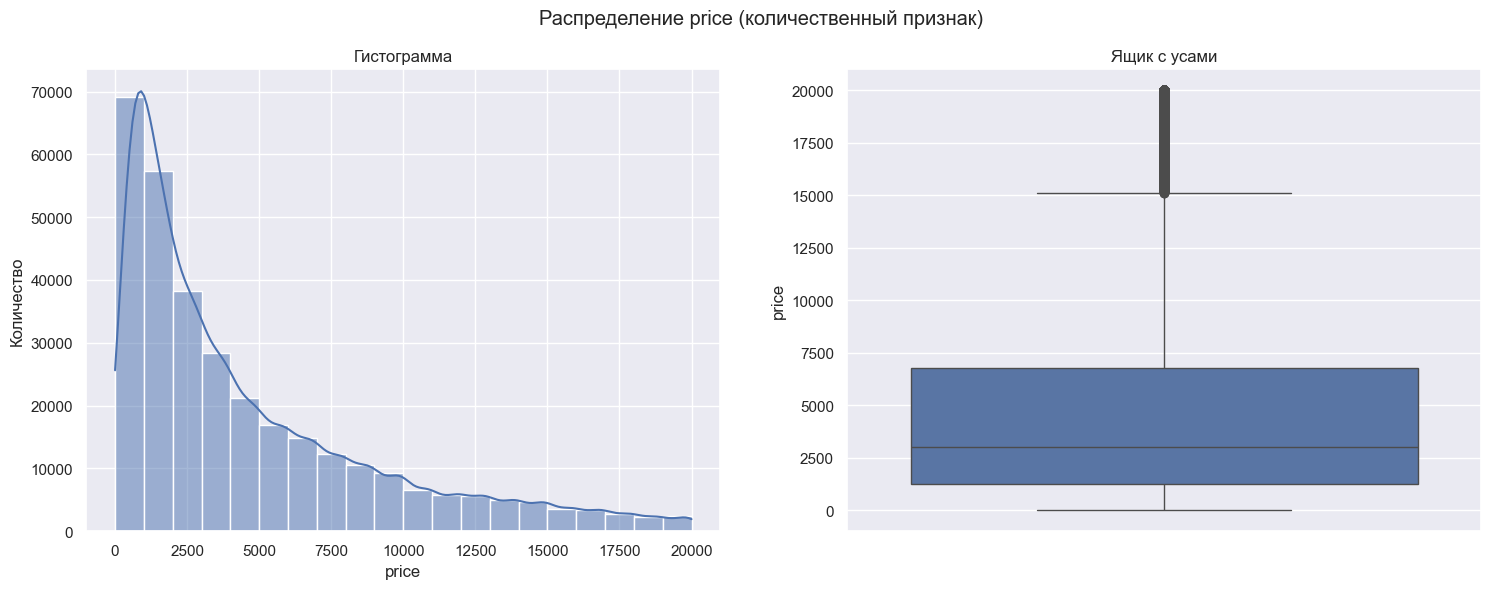

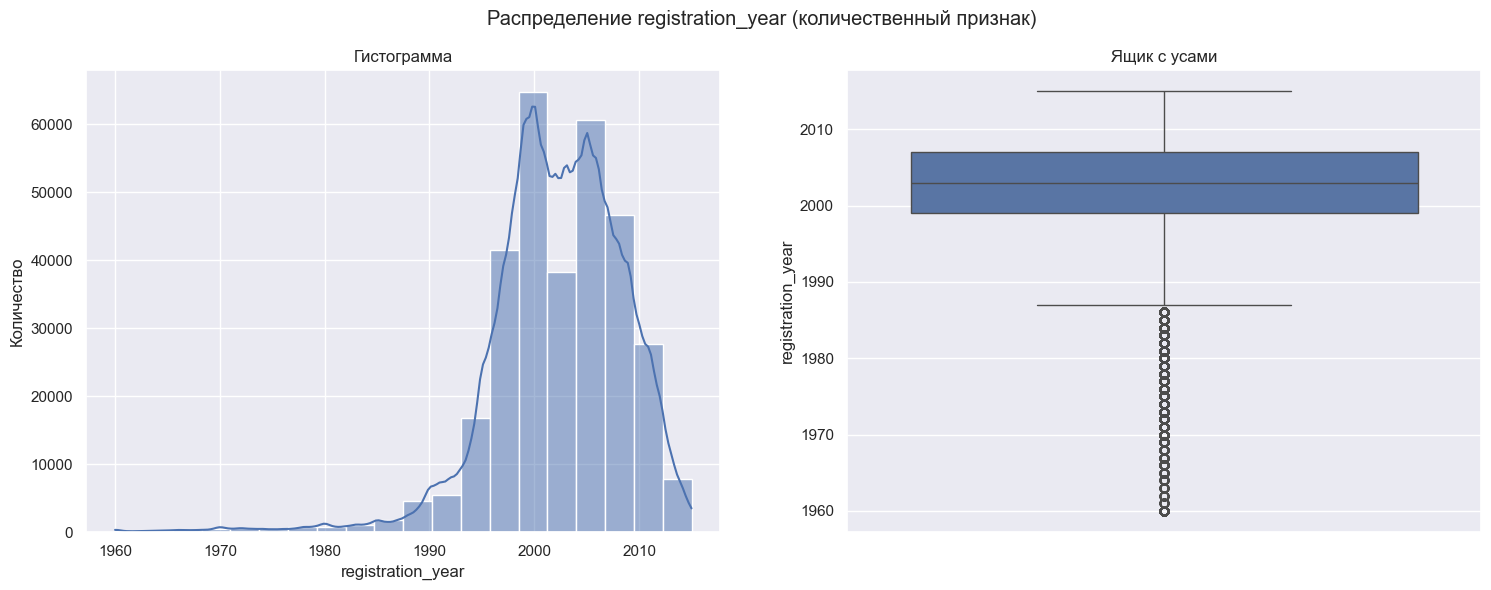

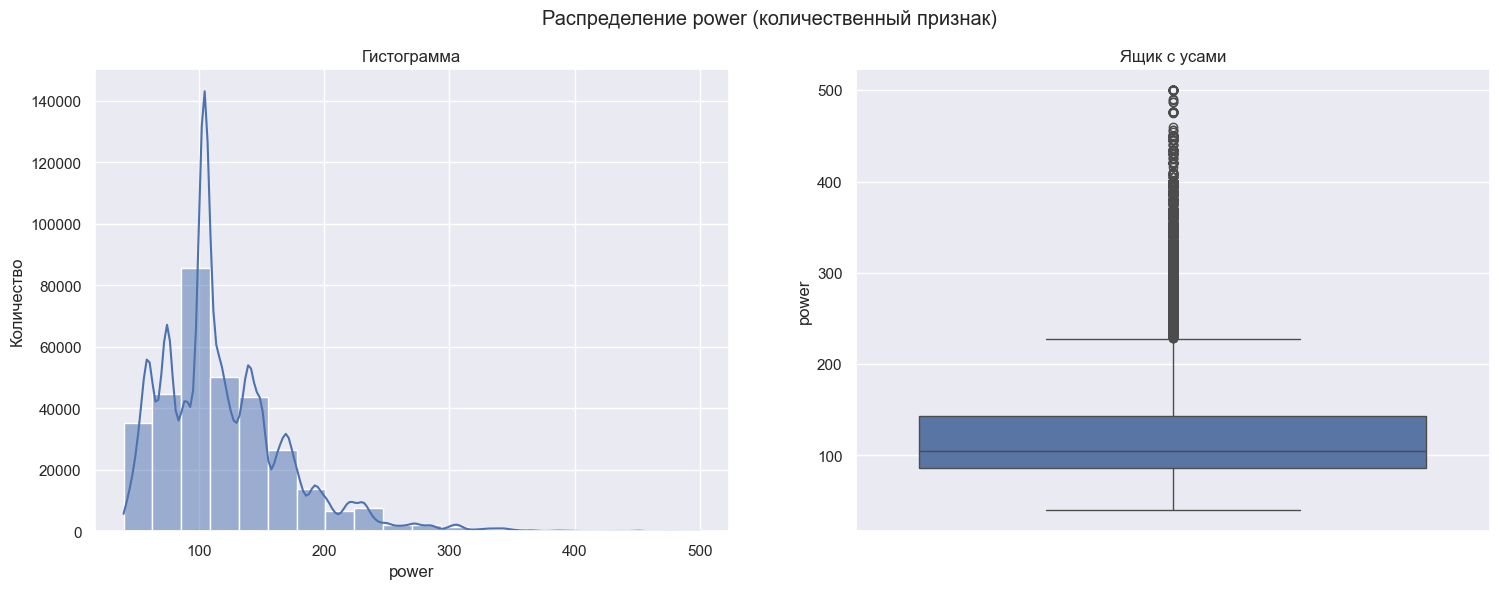

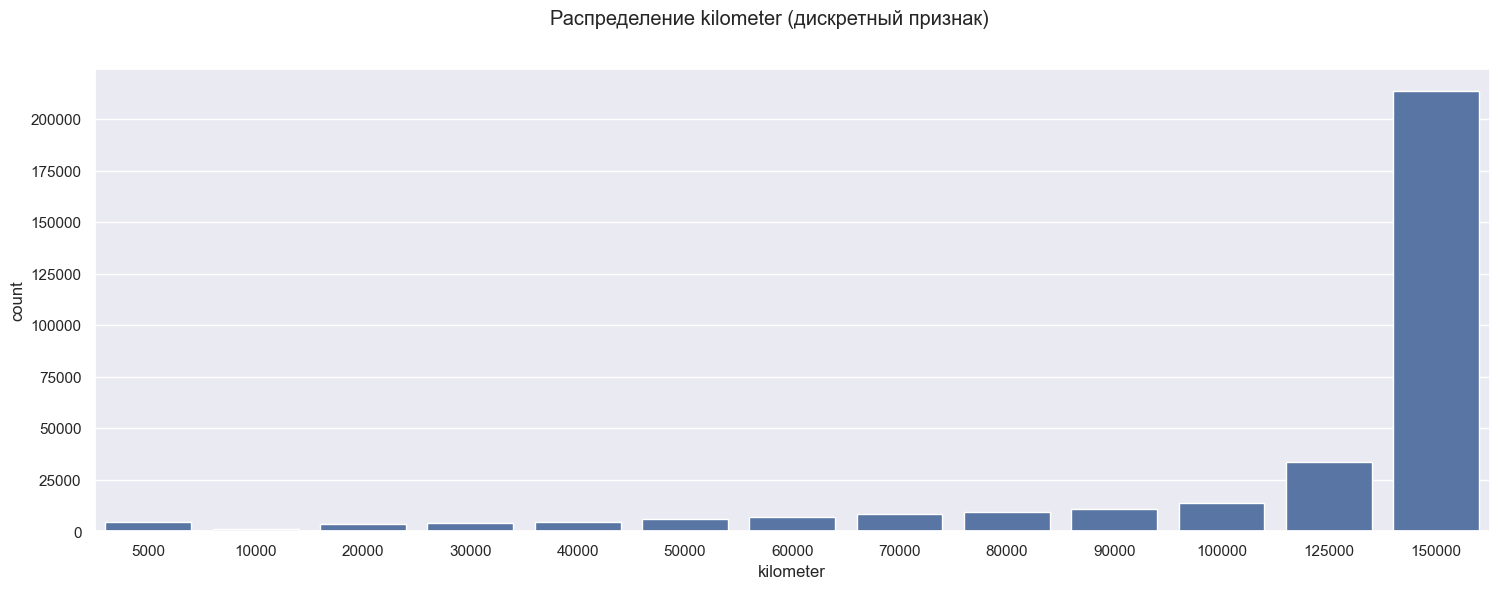

In [41]:
viz_num_features(autos_data,num_features_col)

### Выводы 
`price`: Распределение сильно смещено влево, большинство автомобилей имеют низкую цену. Наблюдается большое количество выбросов в сторону высоких цен, что указывает на наличие редких дорогих предложений.

`registration_year`: Основная масса автомобилей зарегистрирована после 2000 года. Имеются выбросы в виде очень старых автомобилей (до 1960 года), что может быть связано с раритетными моделями

`power`: Распределение также смещено влево — большинство автомобилей имеют мощность до 200 000 условных единиц. Есть значительные выбросы с аномально высокой мощностью (до 500), что может указывать на спецтехнику или спортивные модели.

`kilometer`: Пробег представлен как дискретный признак с явными категориями

### Визуализация категориальных признаков

In [42]:
def vis_cat_features(df, column):
    for col in column:
        unique_values = df[col].nunique()
        plt.figure(figsize=(18,6))
        if unique_values > 15:
            top_values = df.value_counts(col).sort_values(ascending=False)[:15].index
            df_top = df[df[col].isin(top_values)]
            
            plot = sns.countplot(data = df_top, y=col)
            plot.set_title(f'Рапределение по {col}. Топ-15', fontsize=16)
        else:
            plot = sns.countplot(data = df, y=col)
            plot.set_title(f'Рапределение по {col}', fontsize=16)
        plt.xlabel('Количество ', fontsize=14)
        plt.ylabel('')
        plt.show()

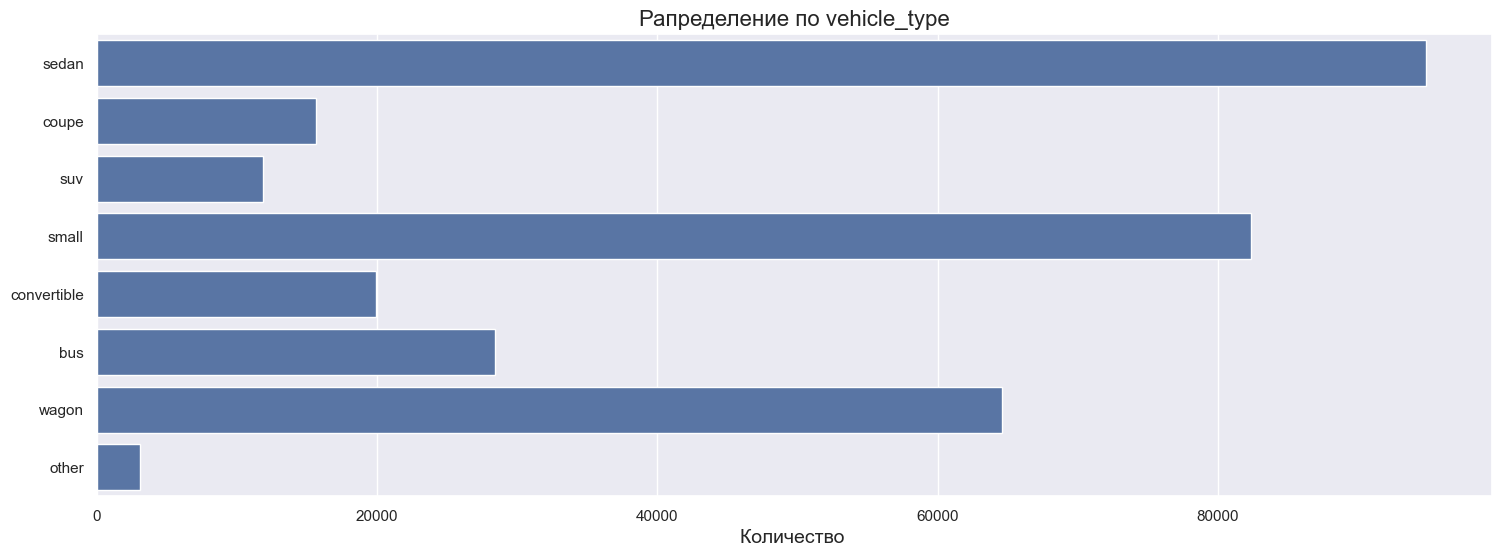

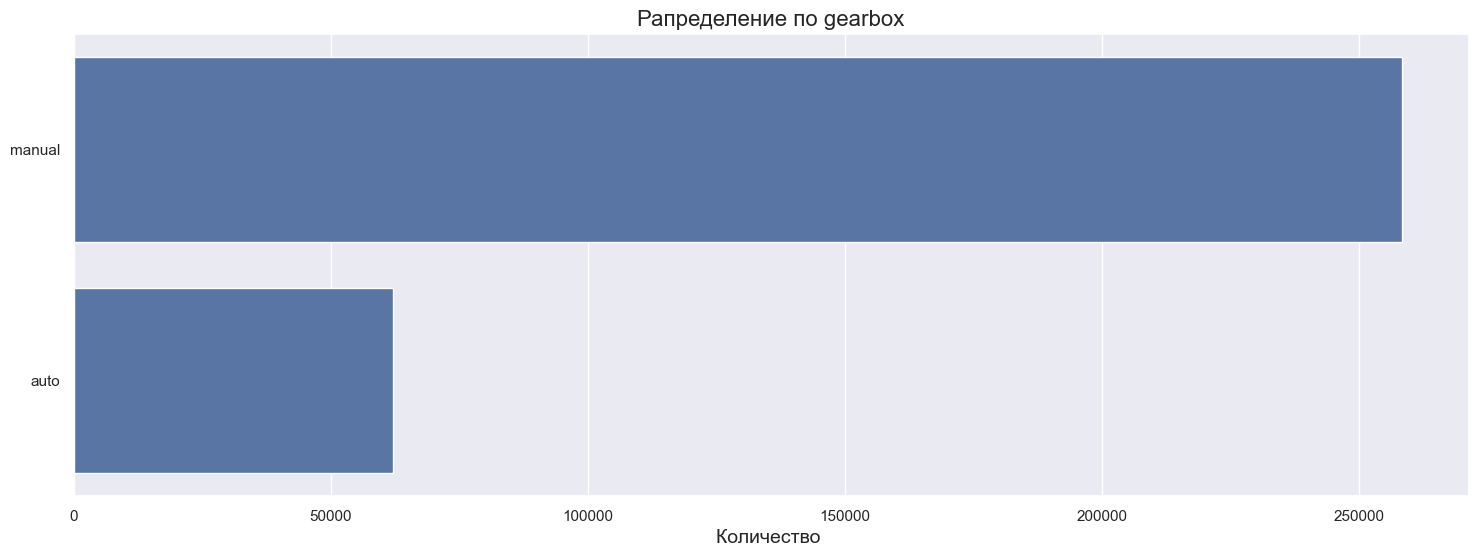

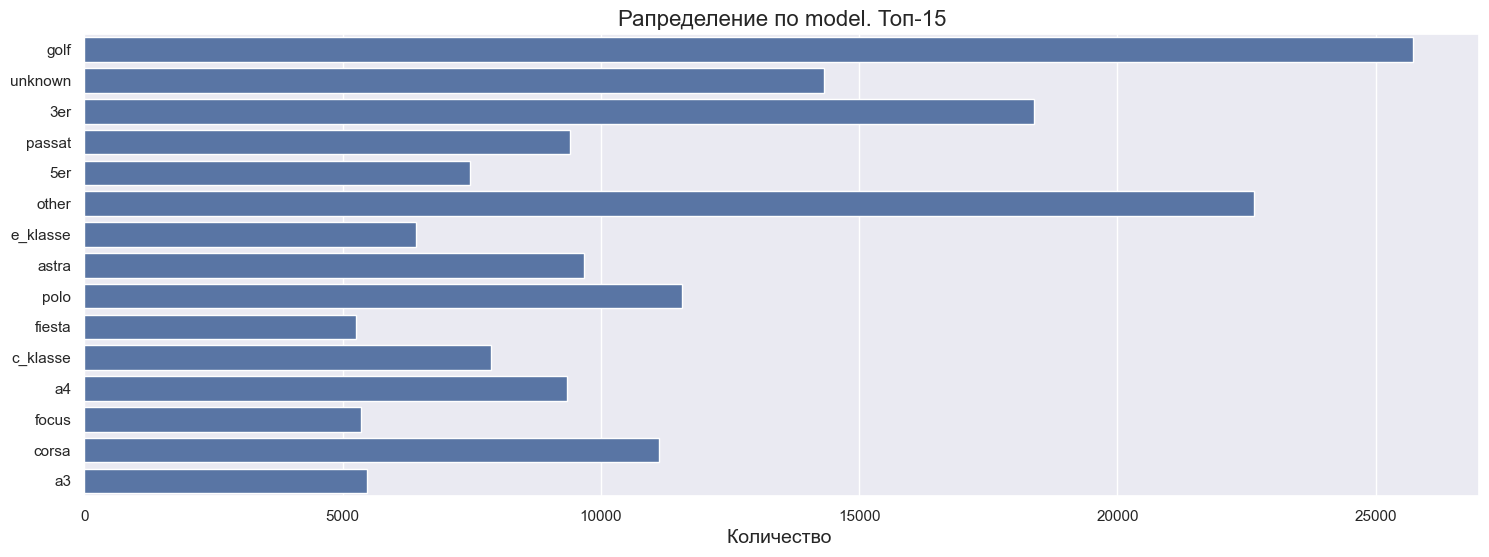

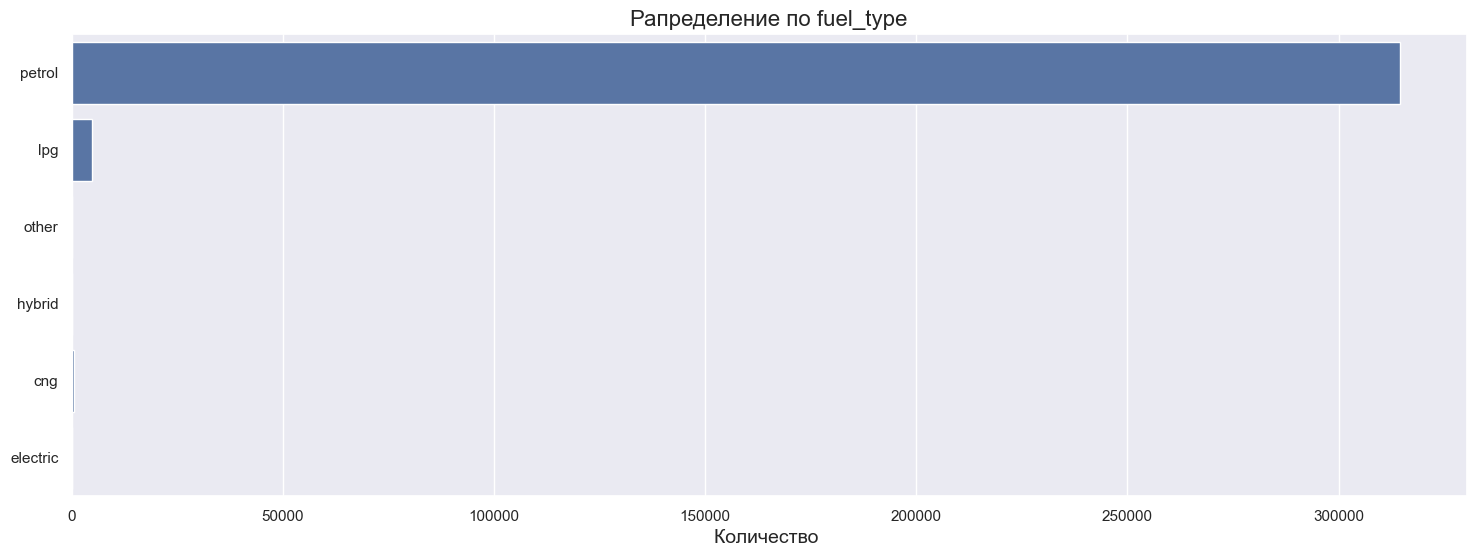

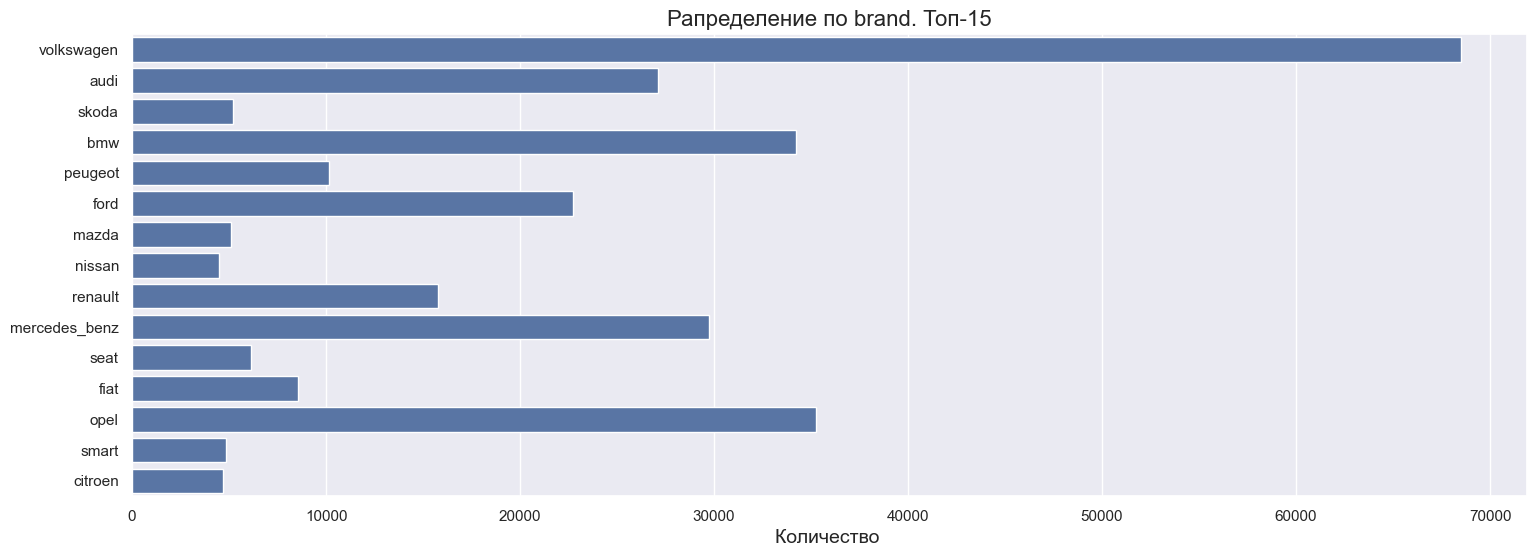

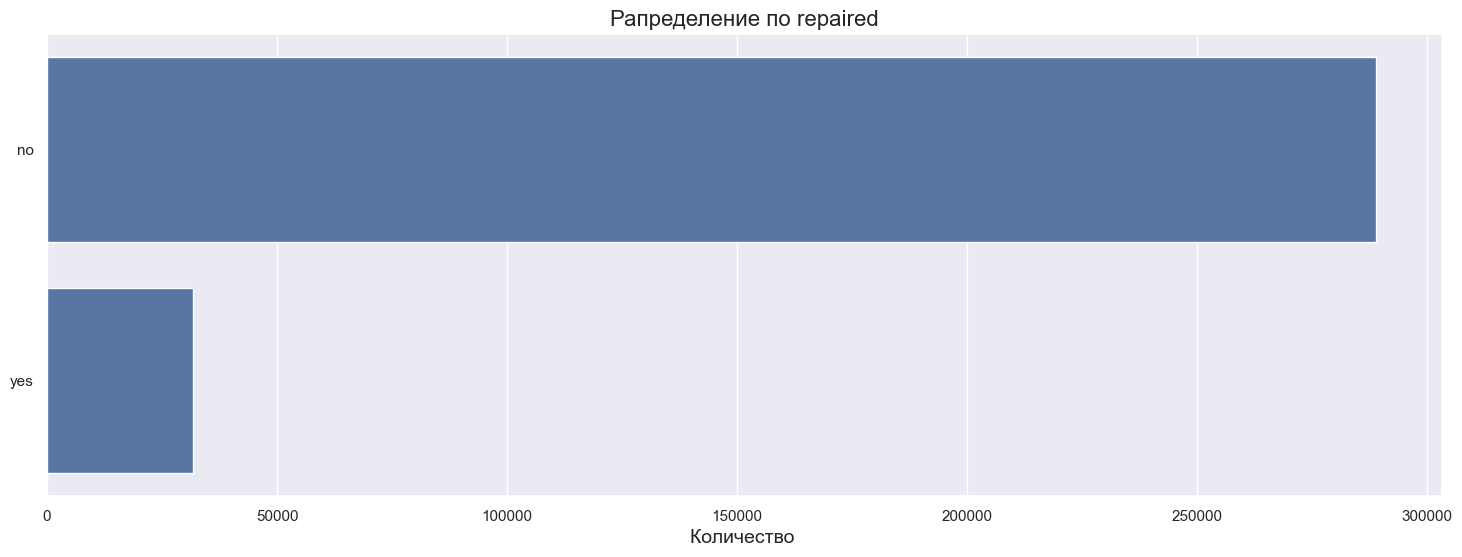

In [43]:
vis_cat_features(autos_data,cat_features_col)

Рассмотрим топ-10 моделей для каждого бренда отдельно.

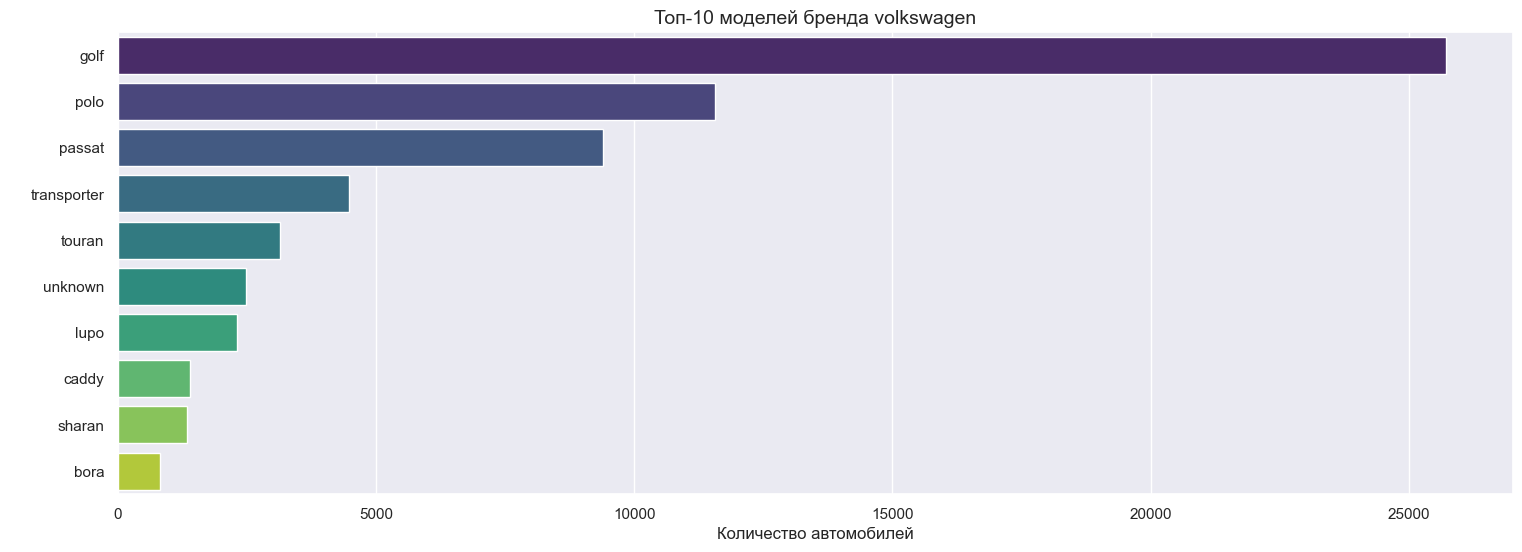

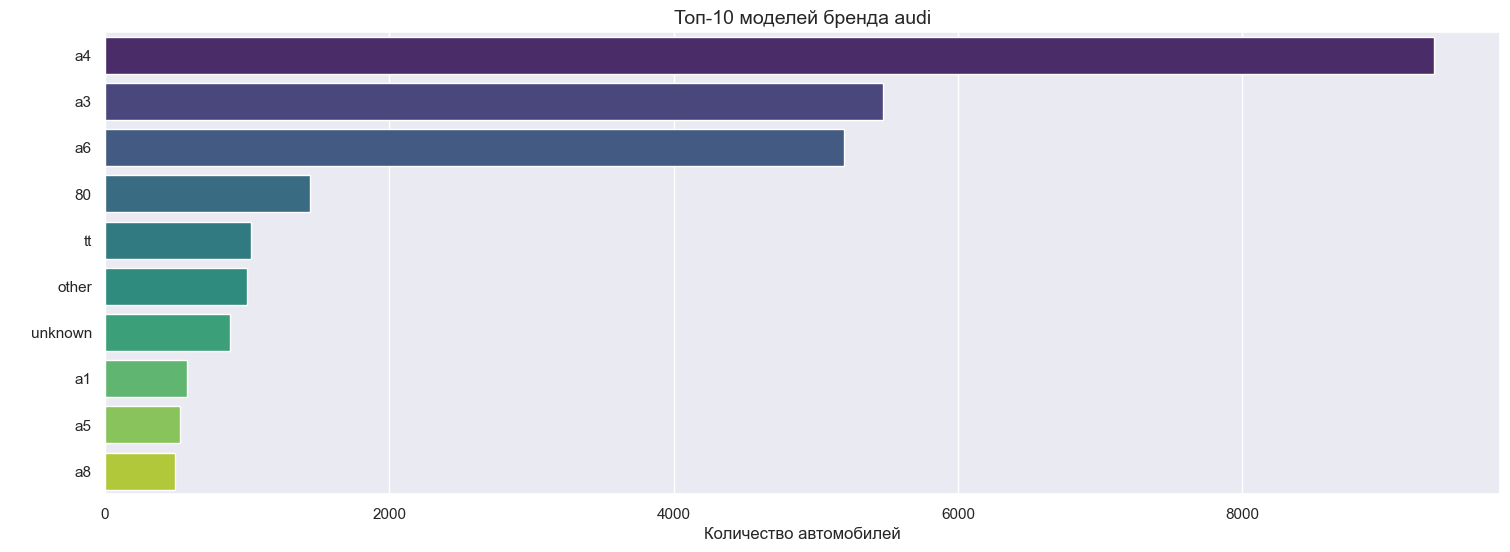

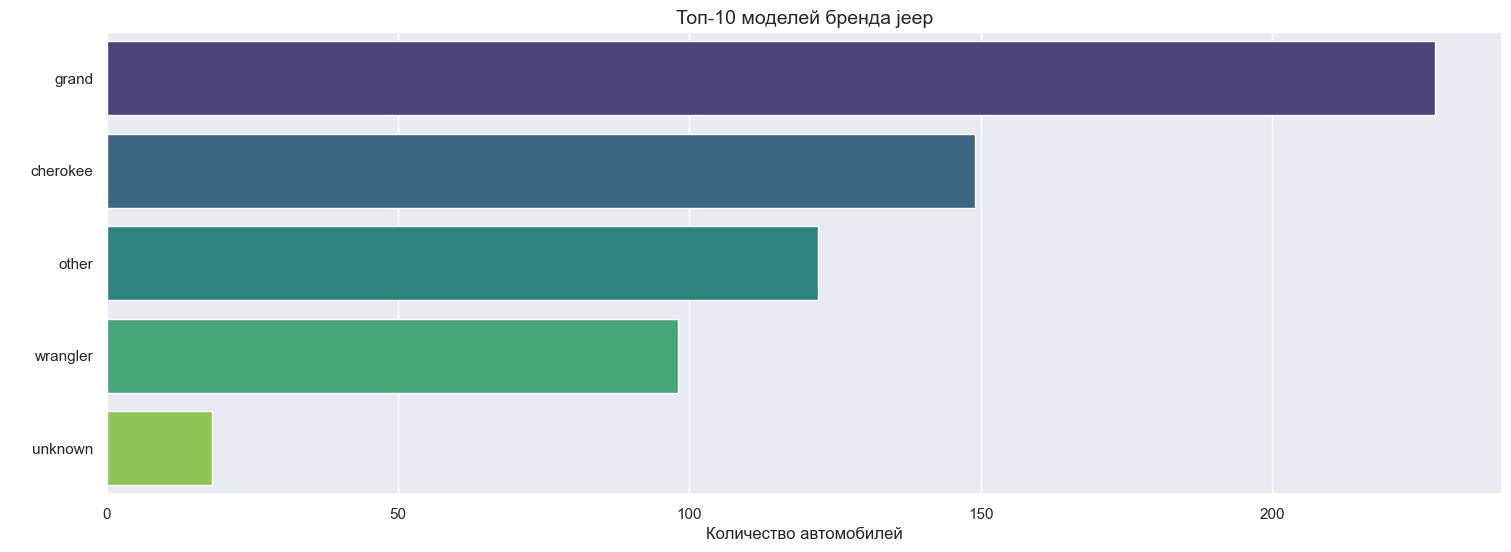

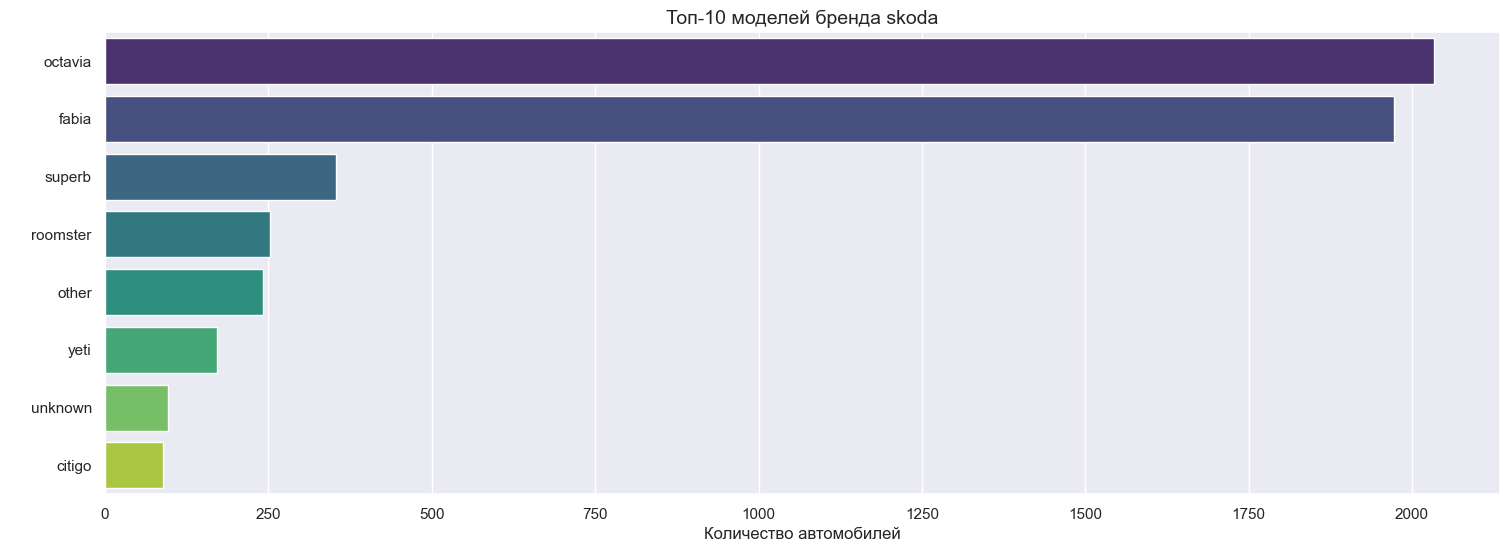

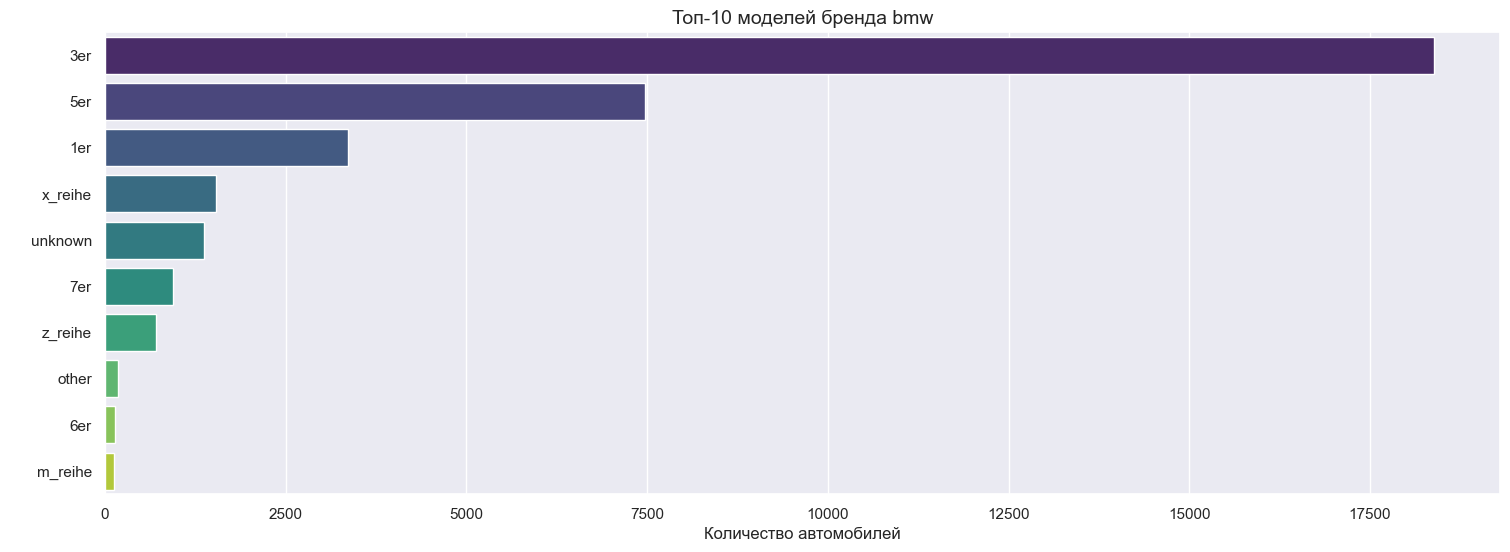

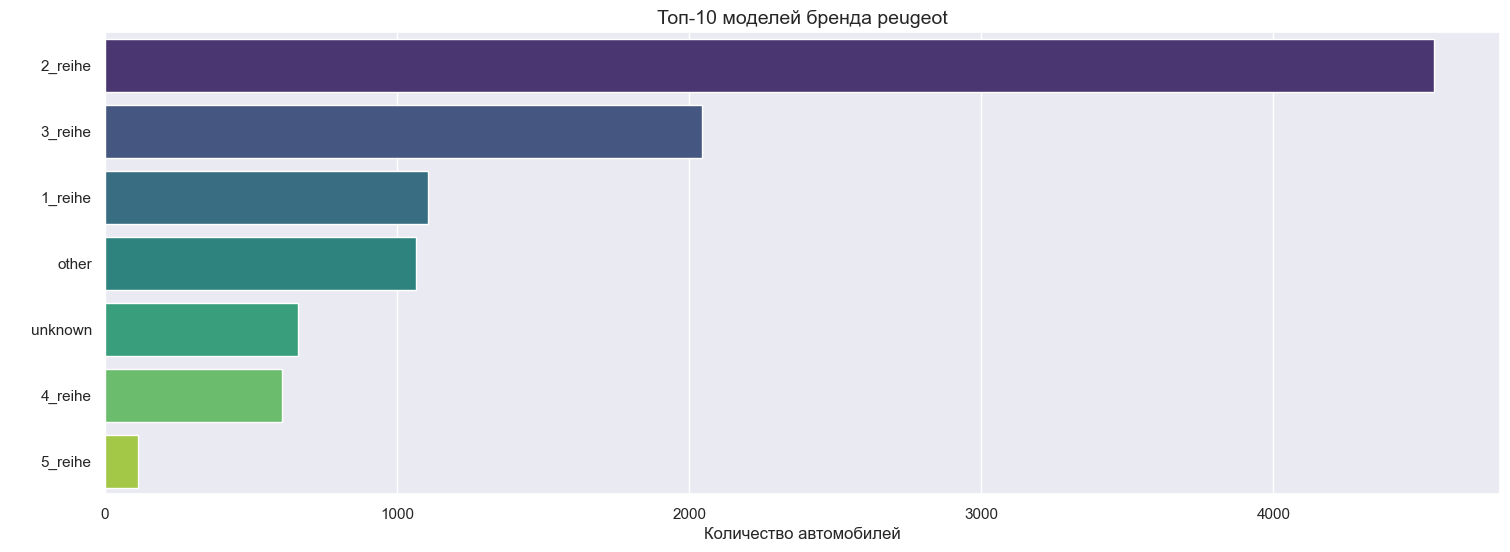

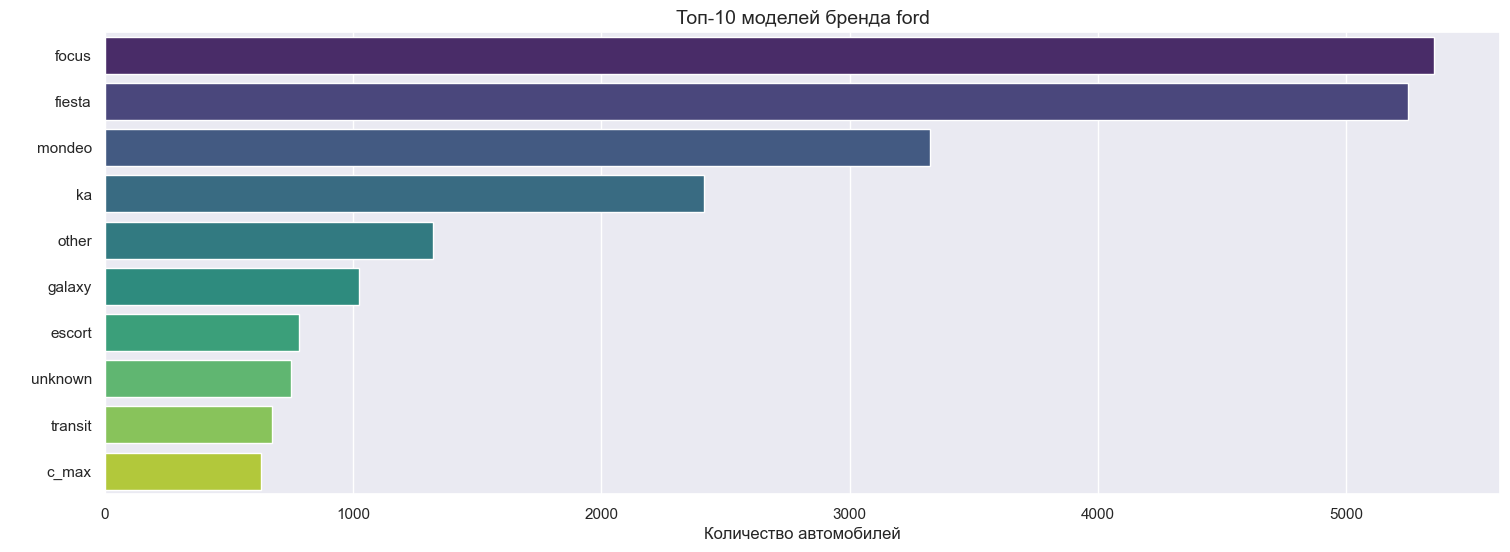

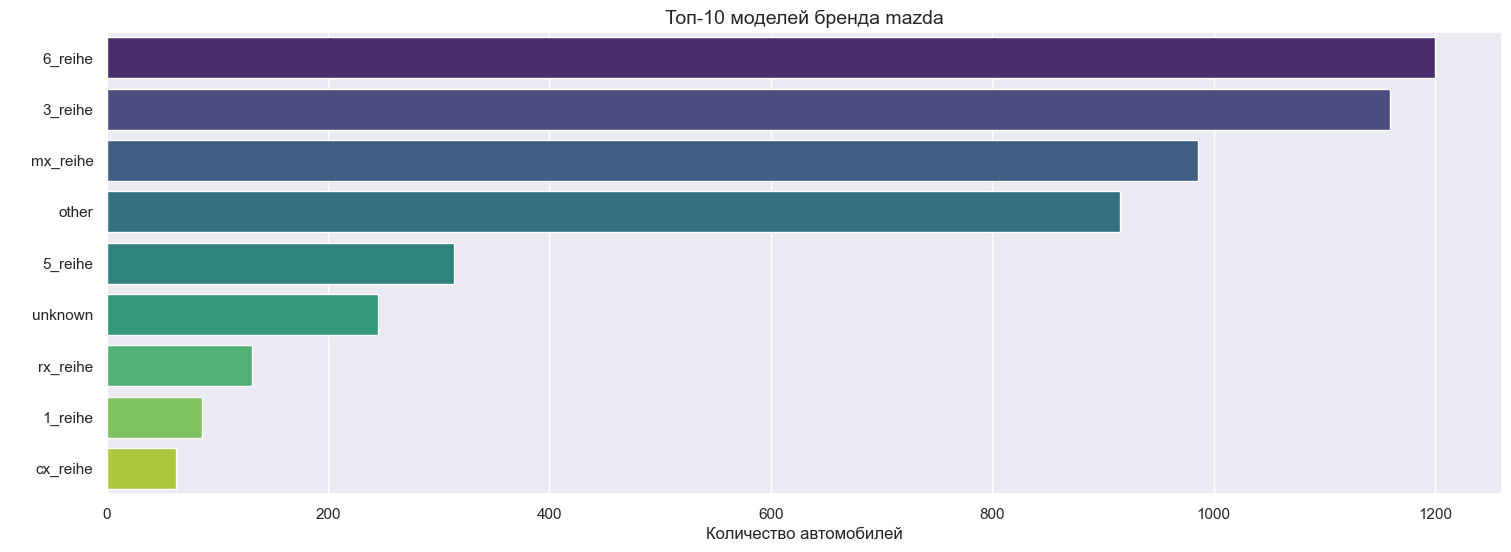

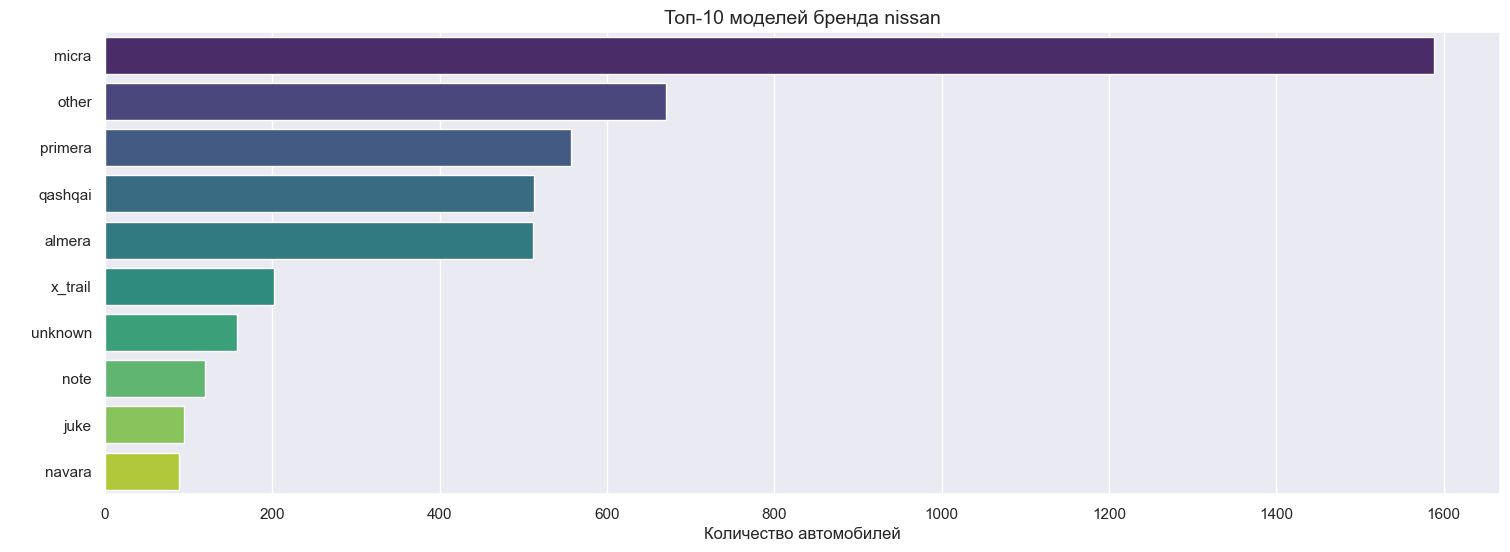

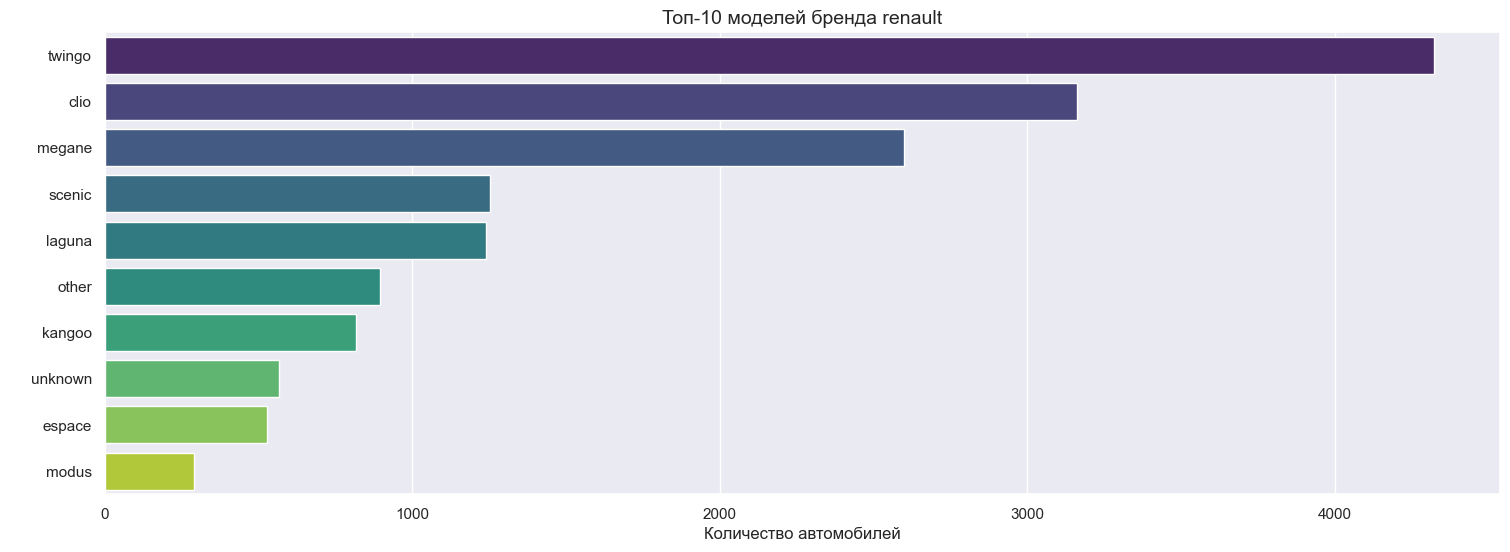

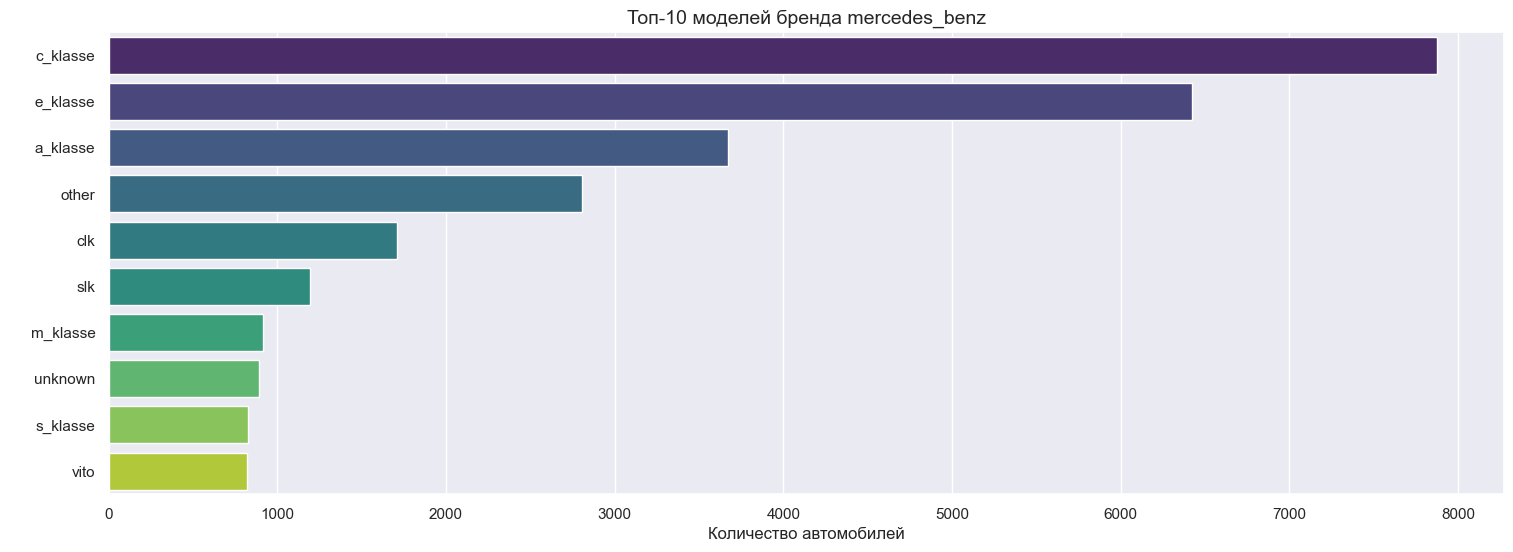

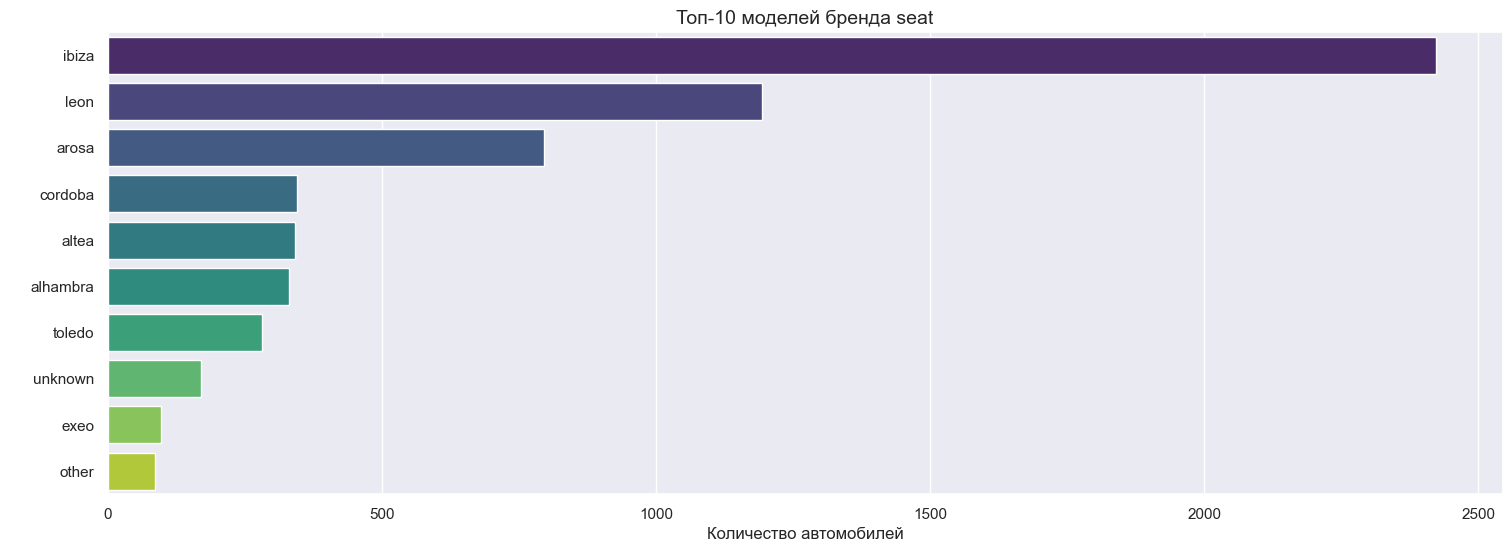

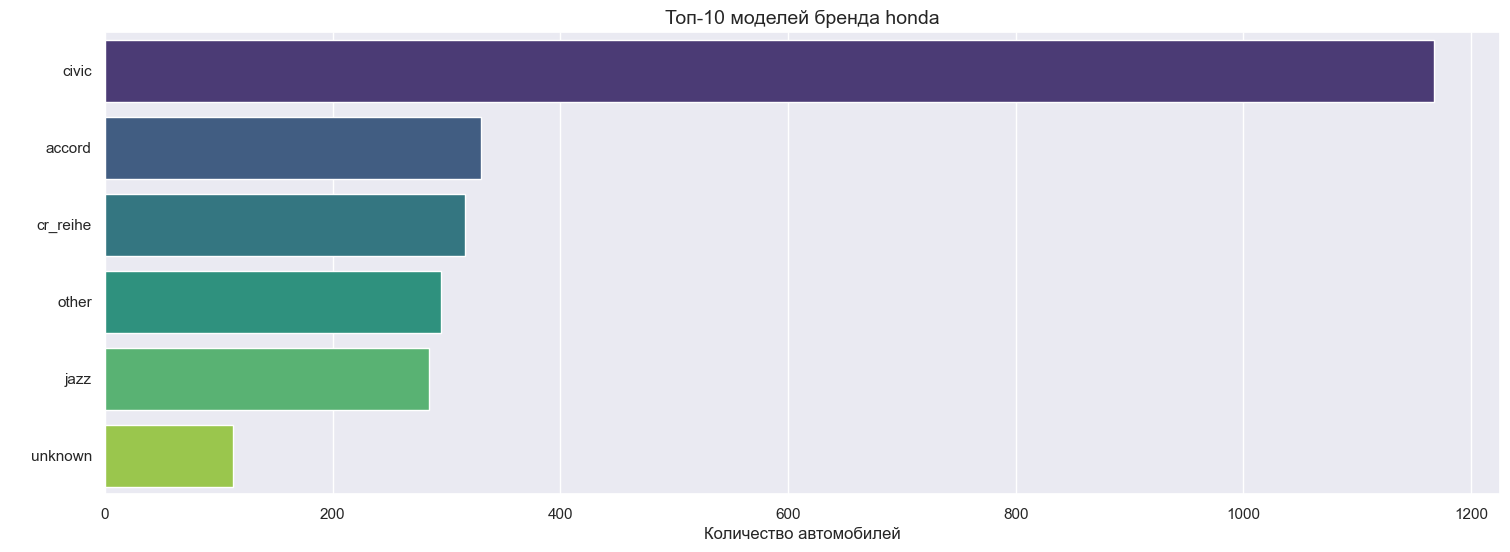

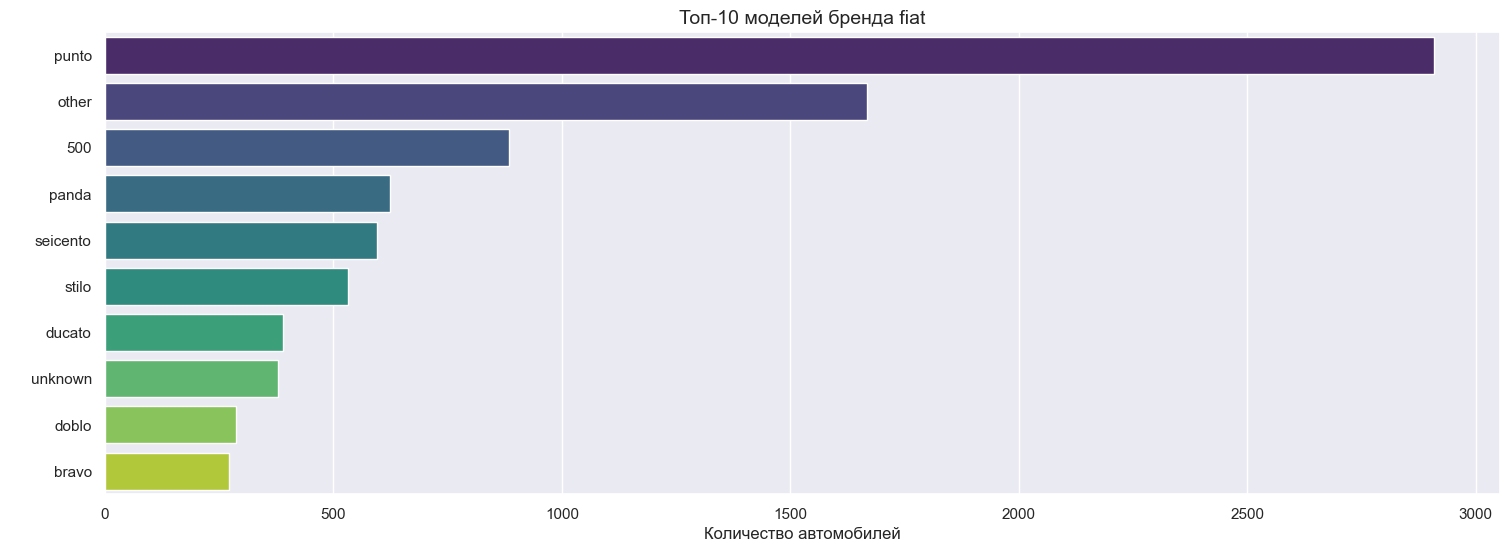

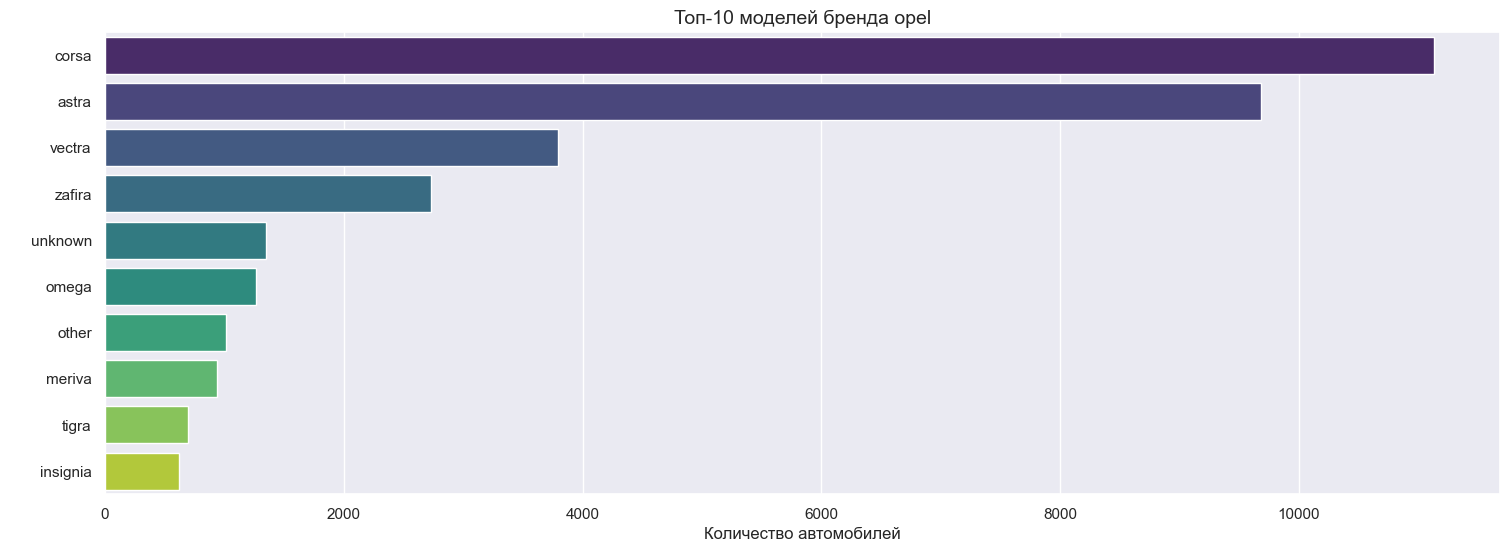

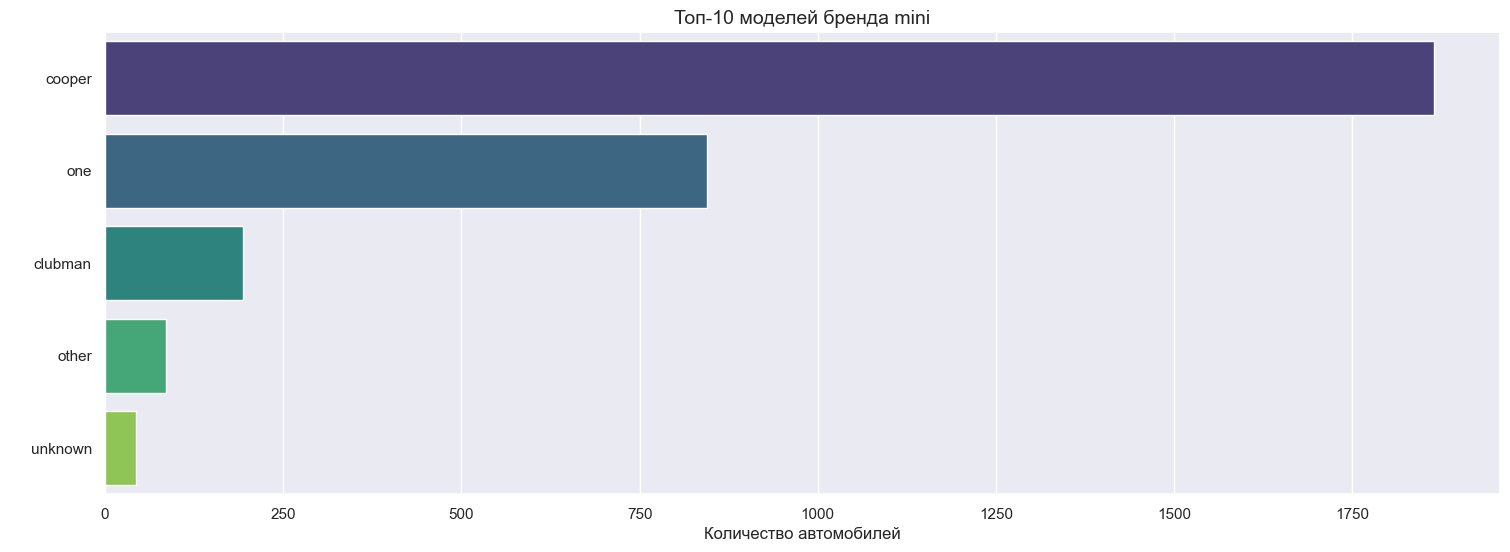

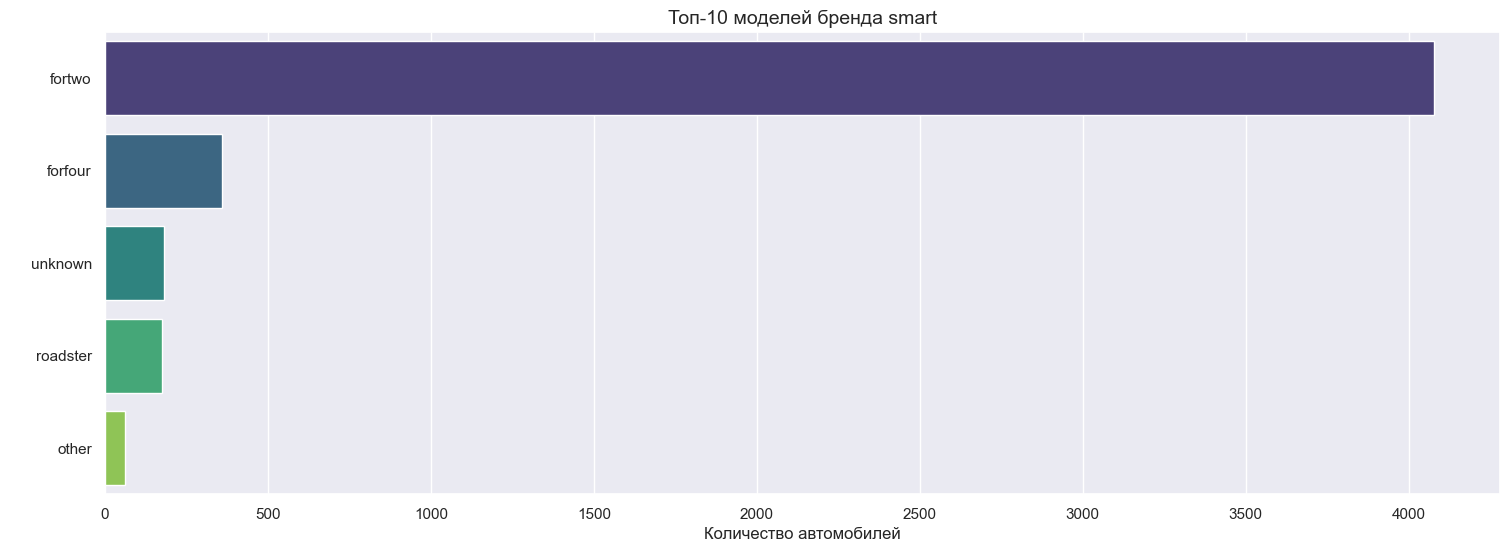

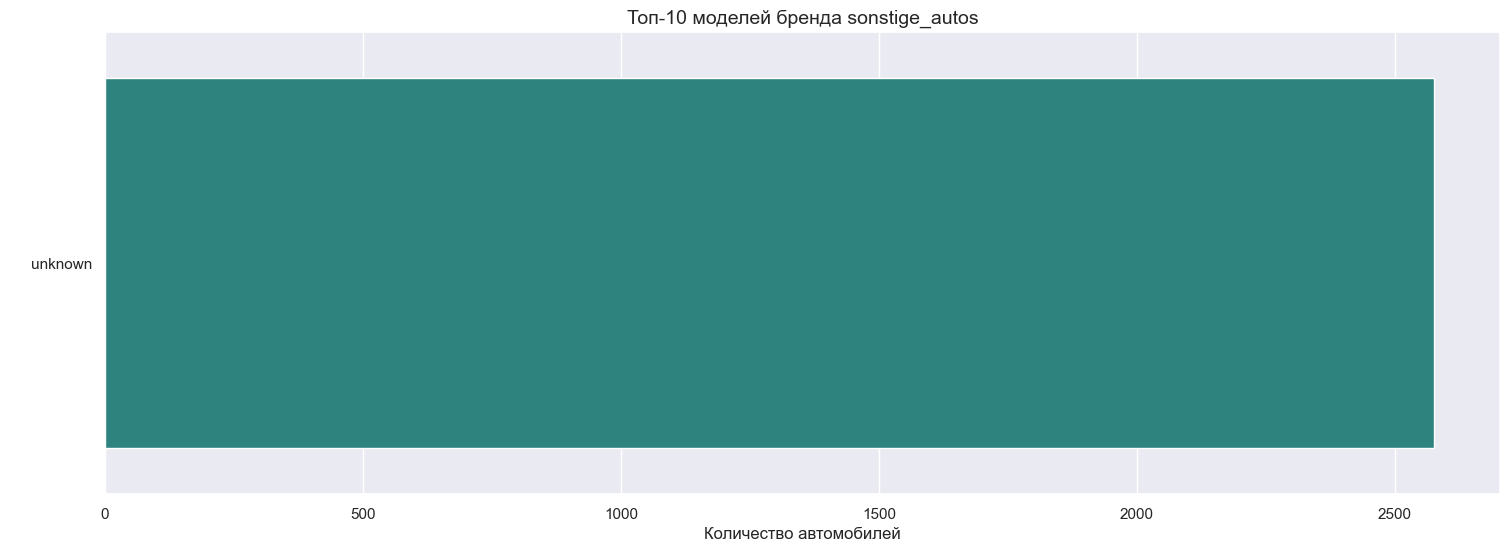

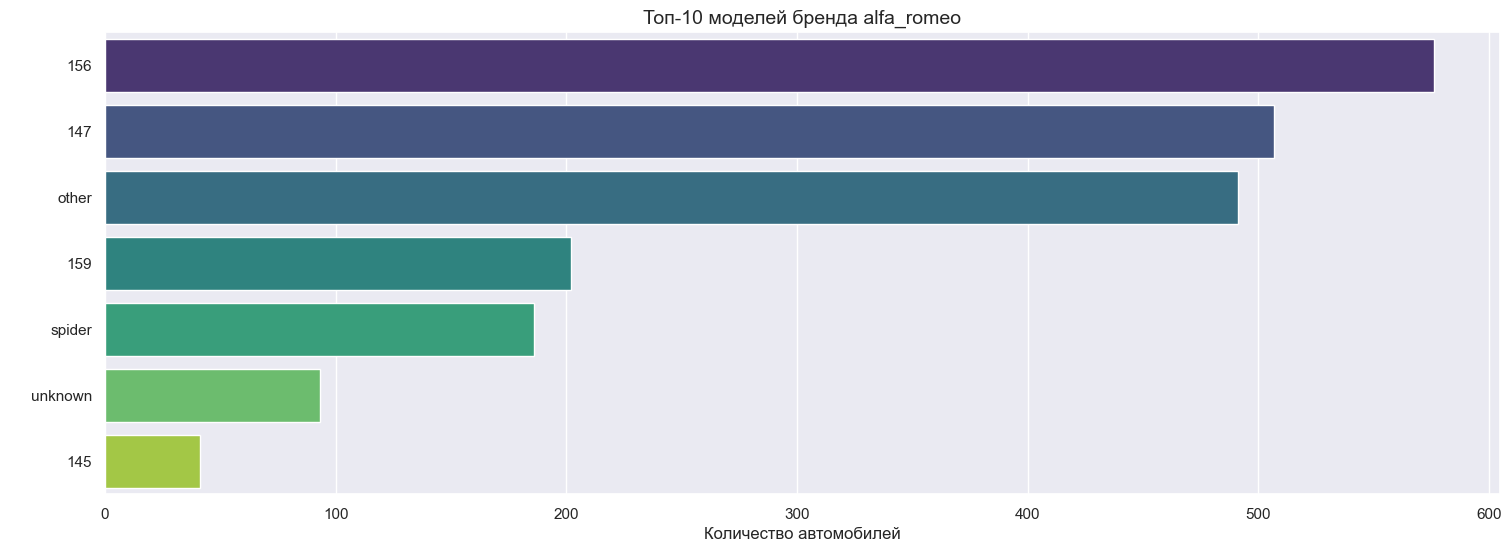

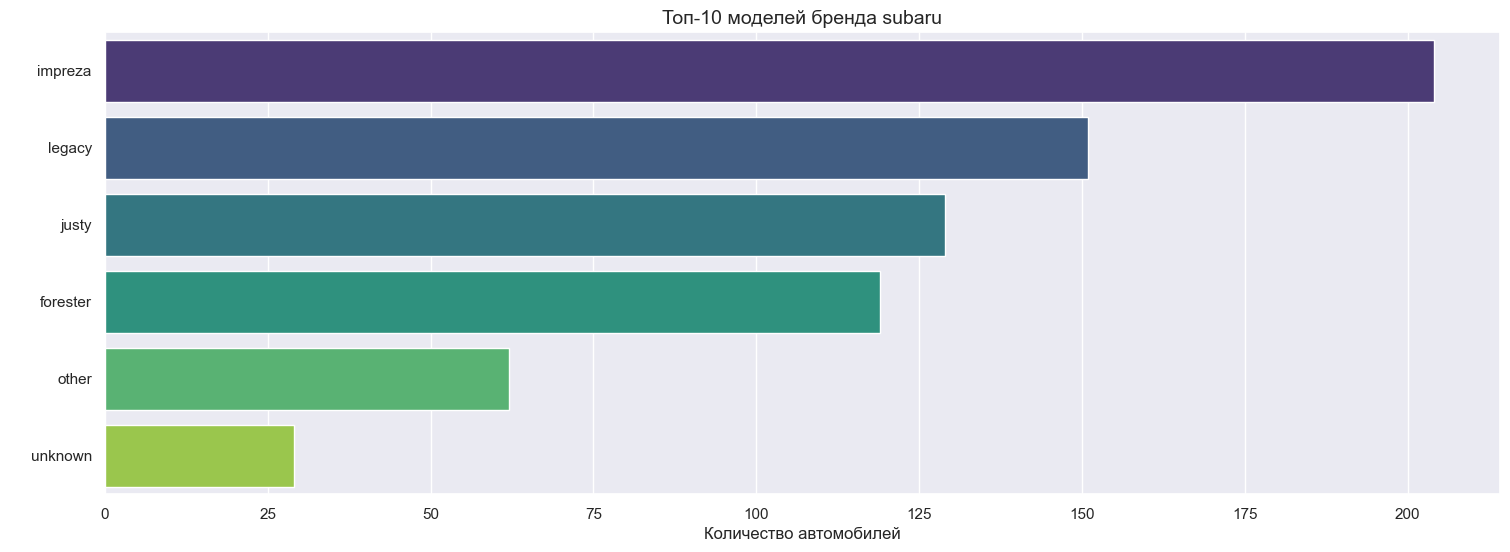

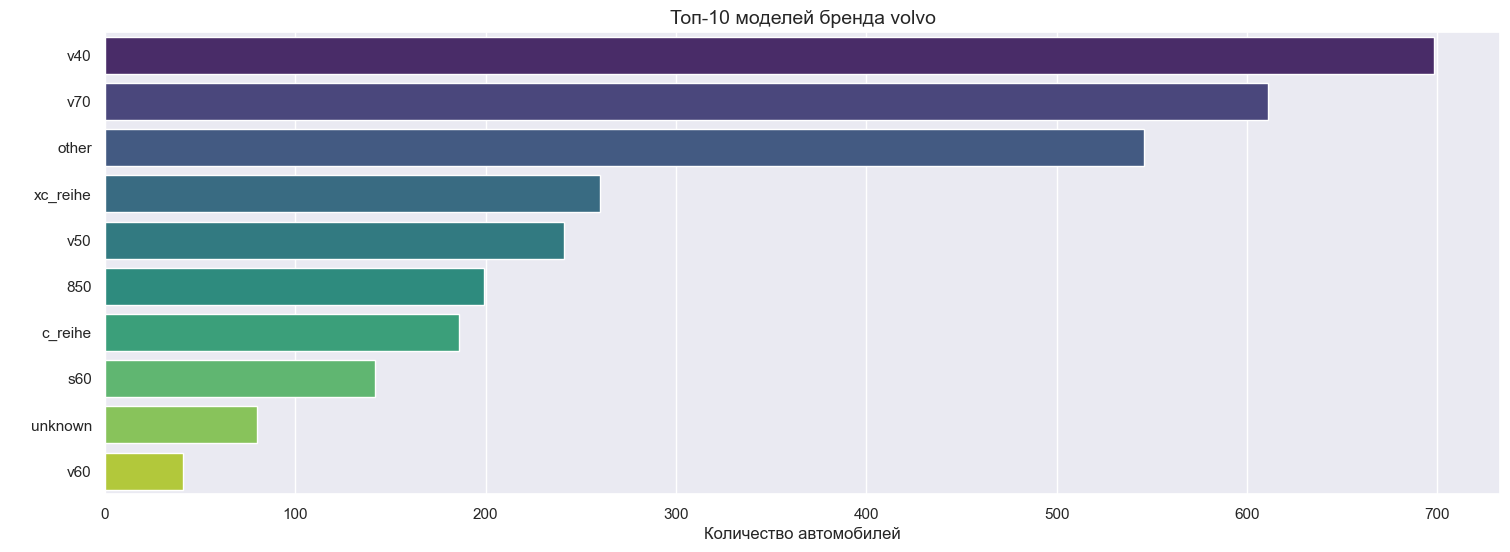

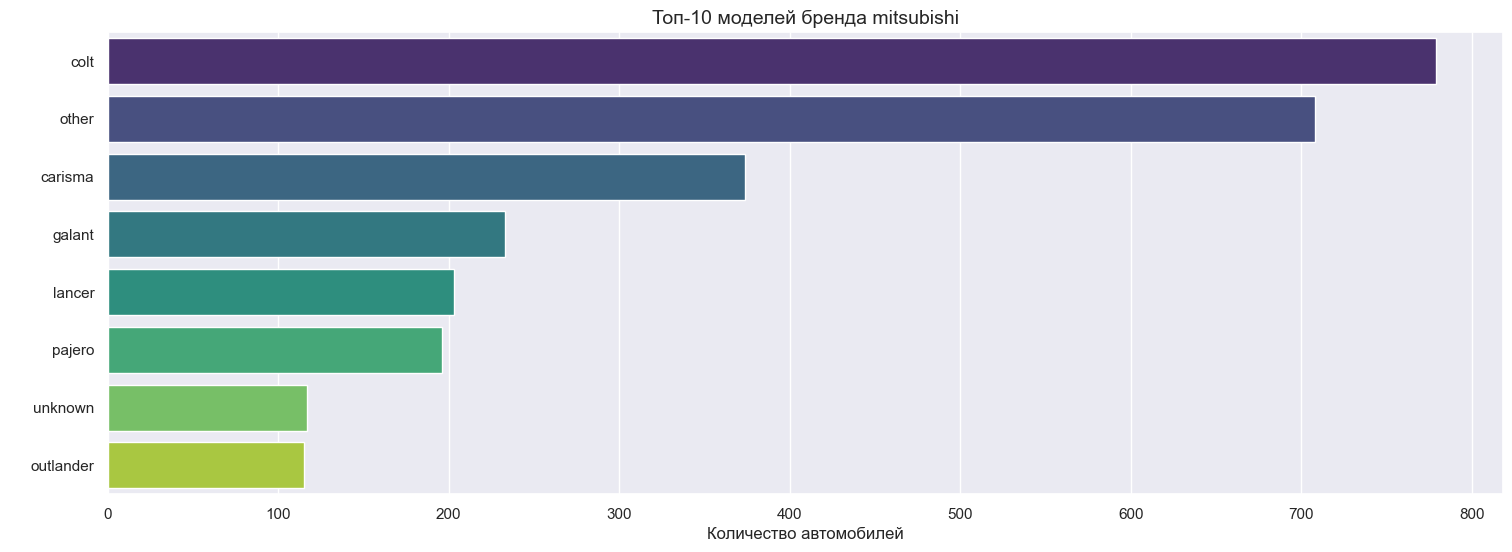

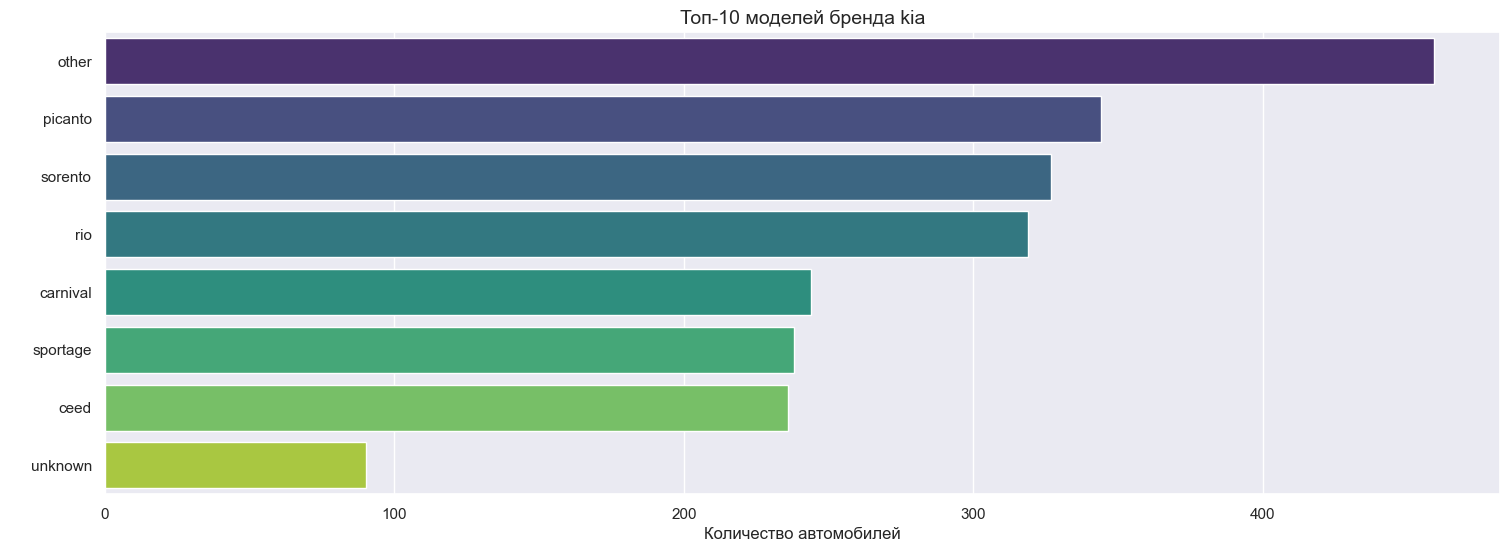

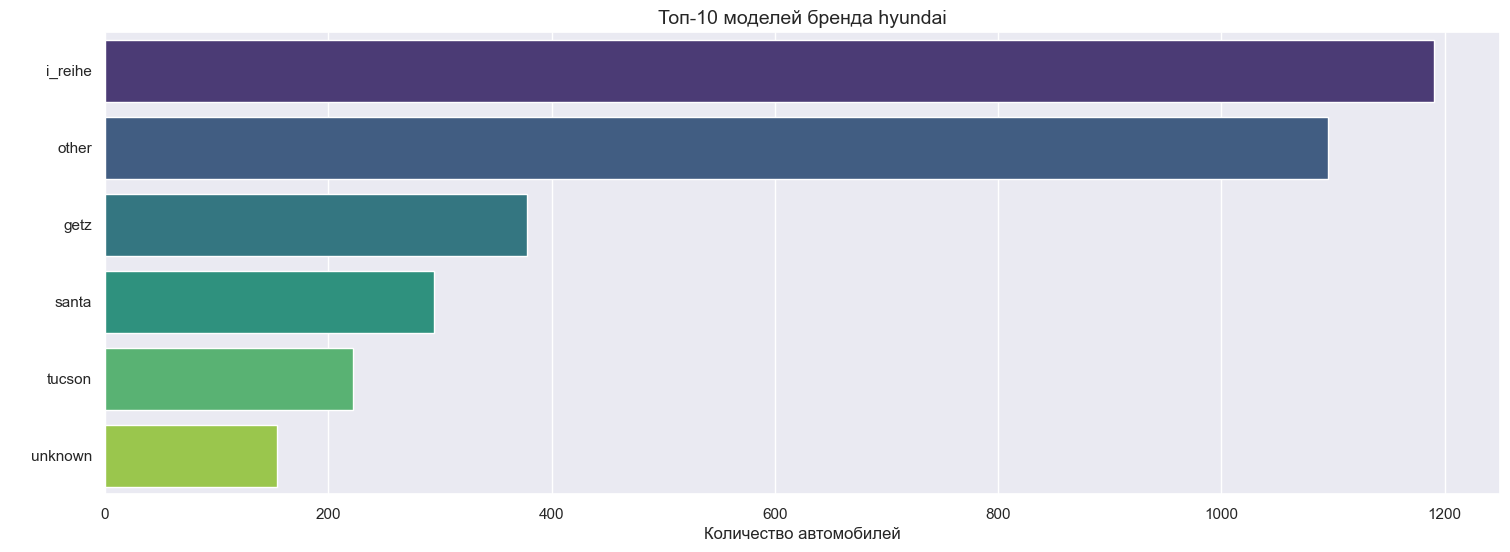

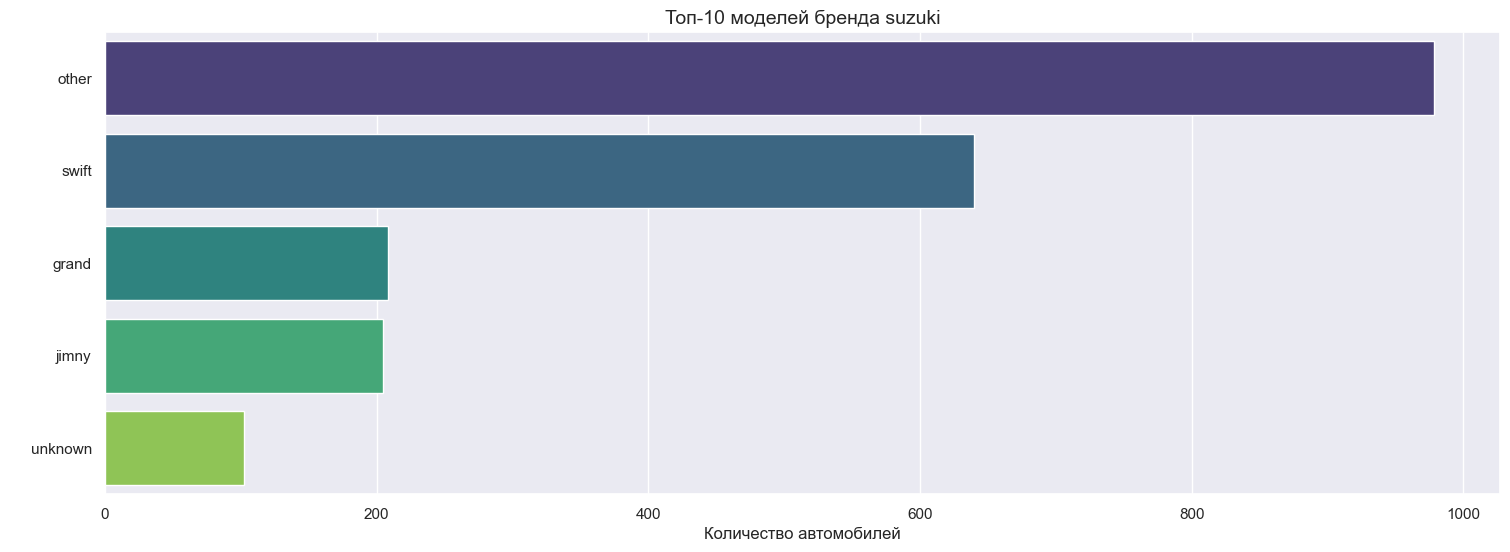

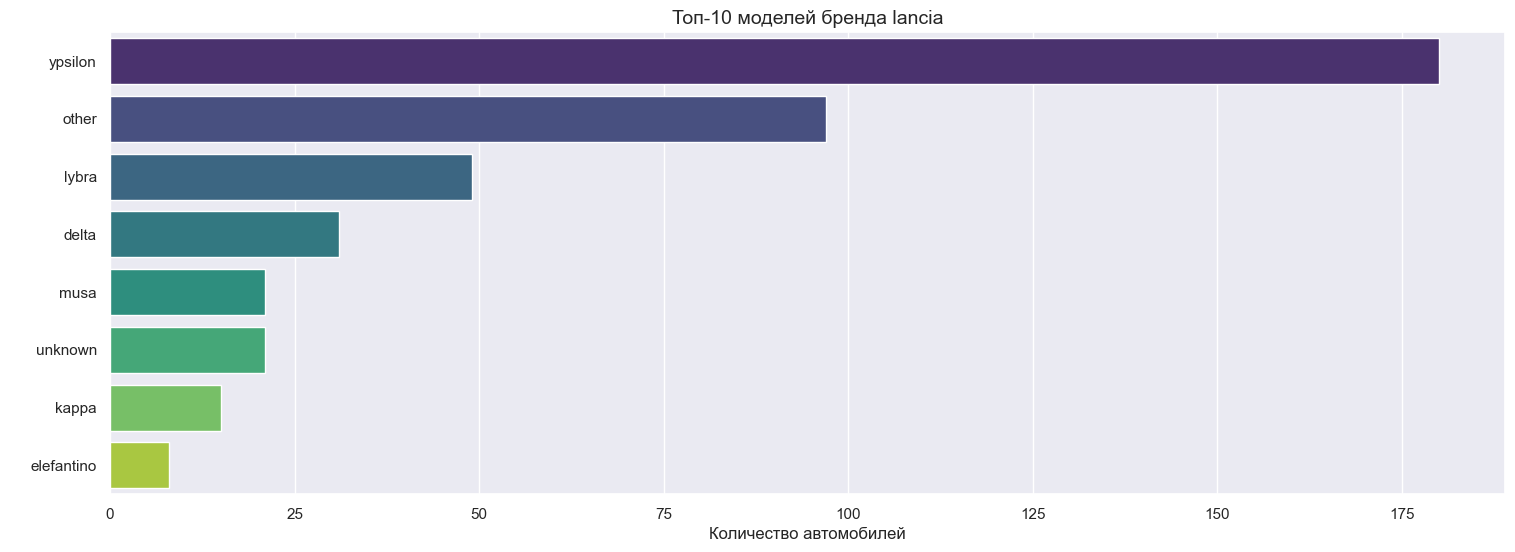

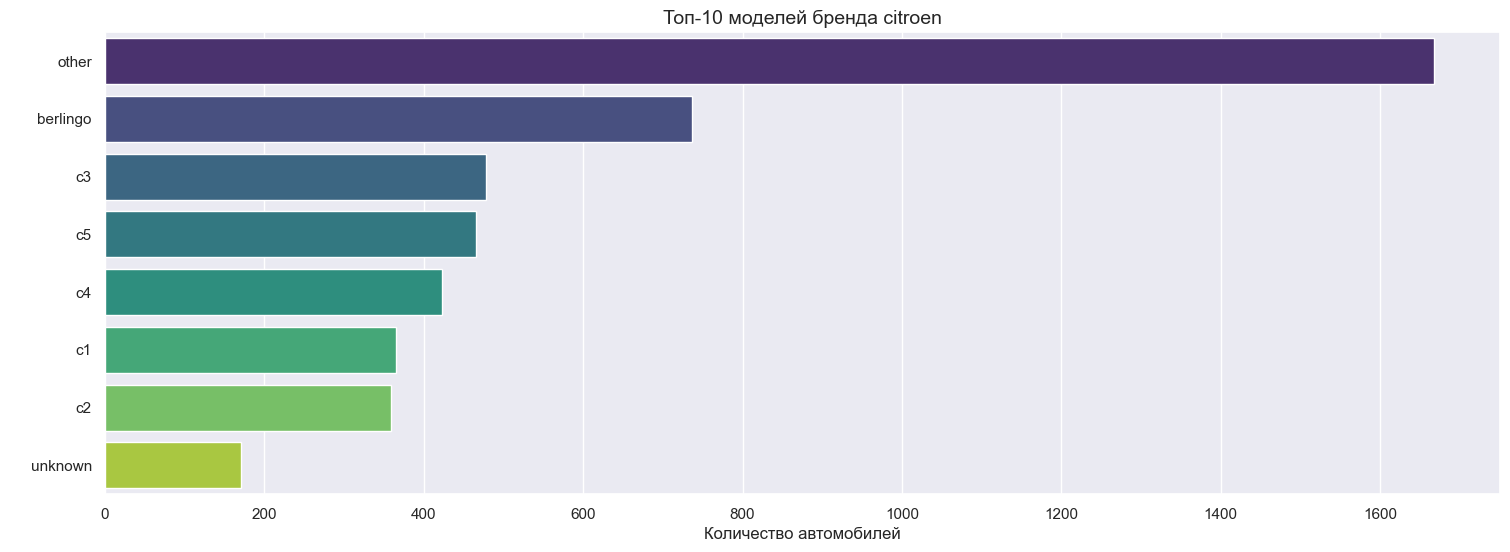

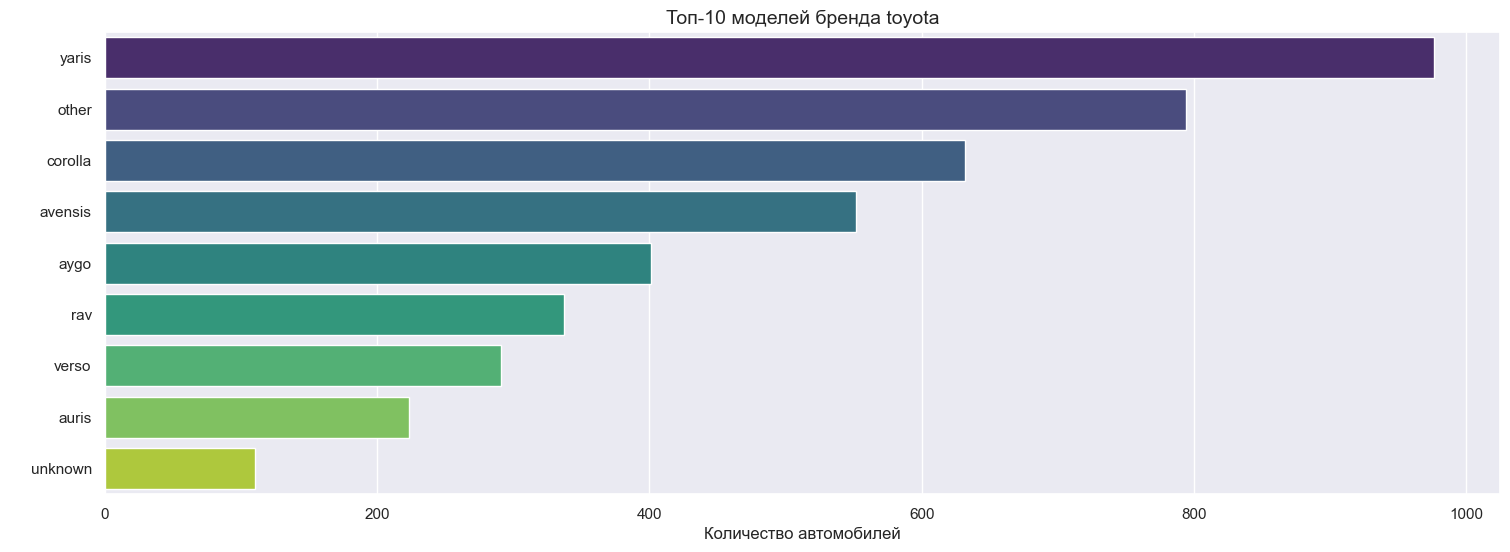

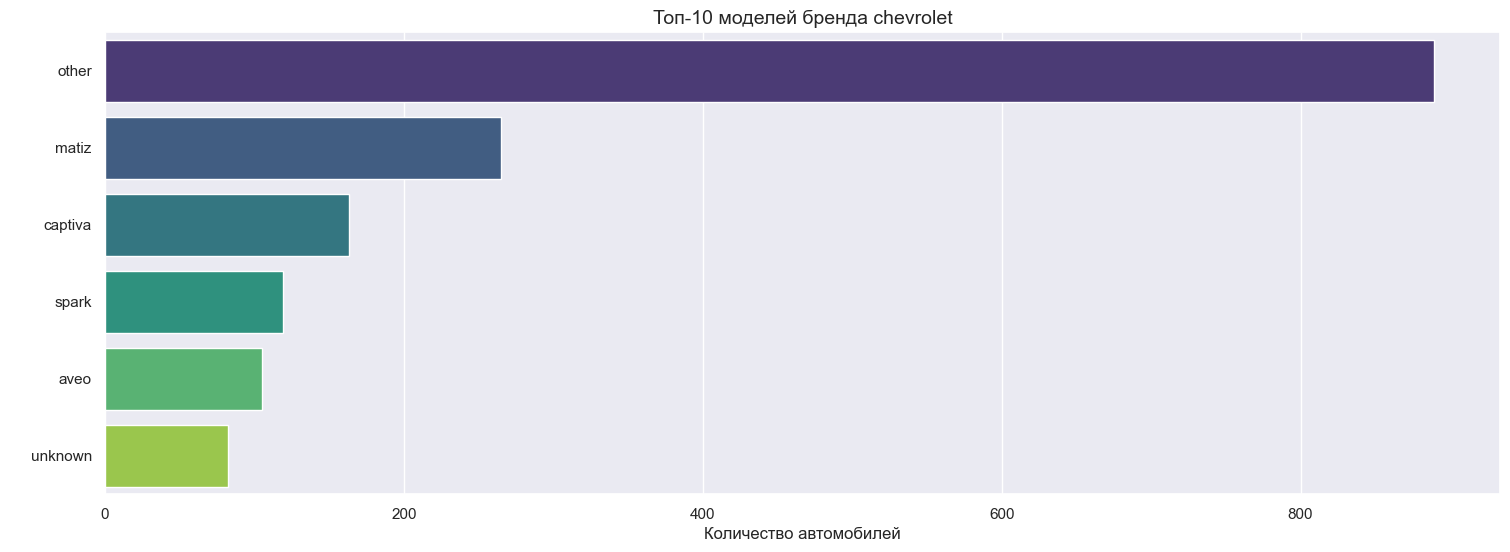

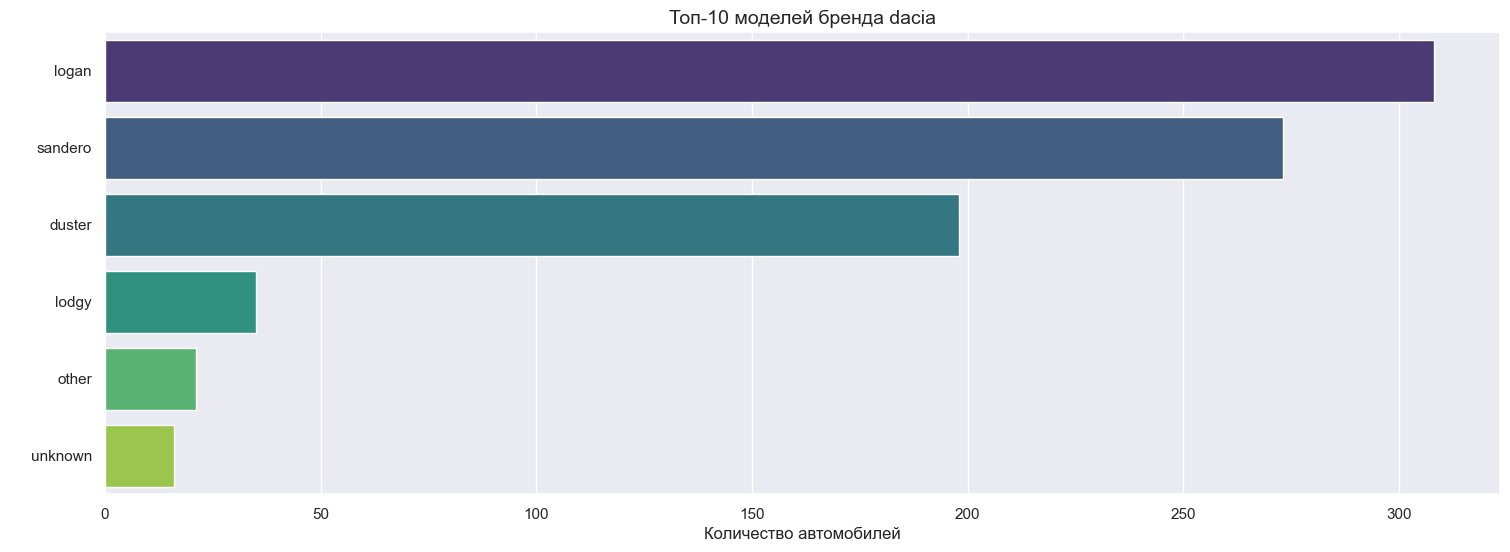

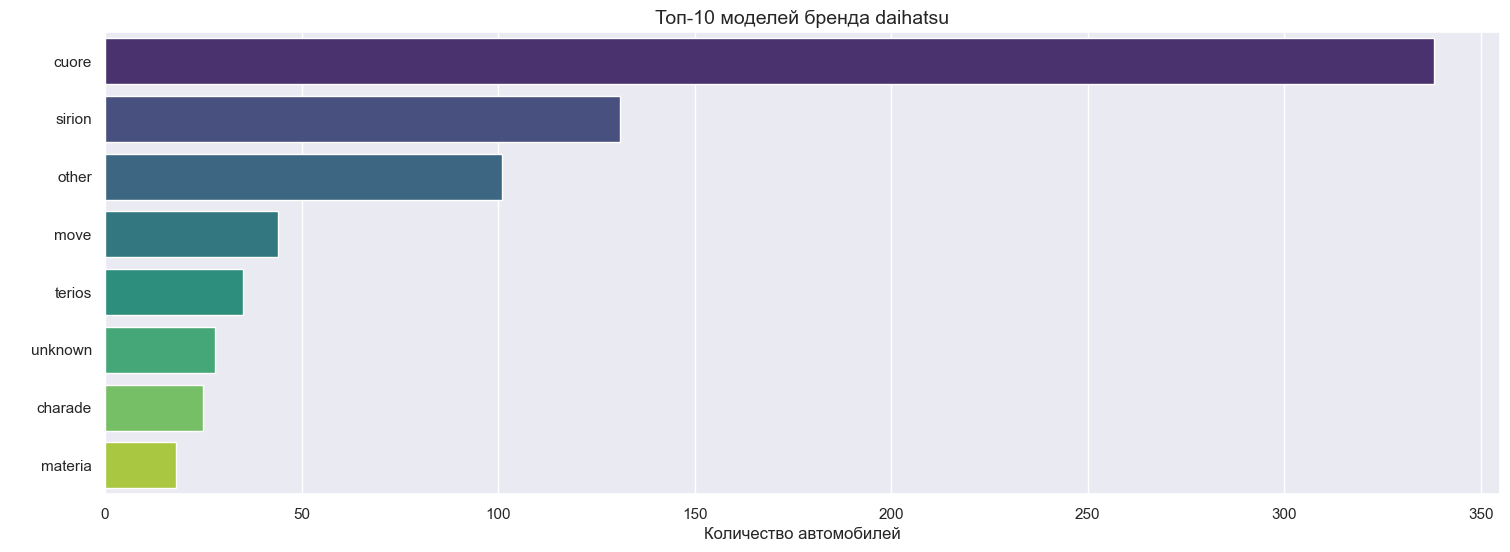

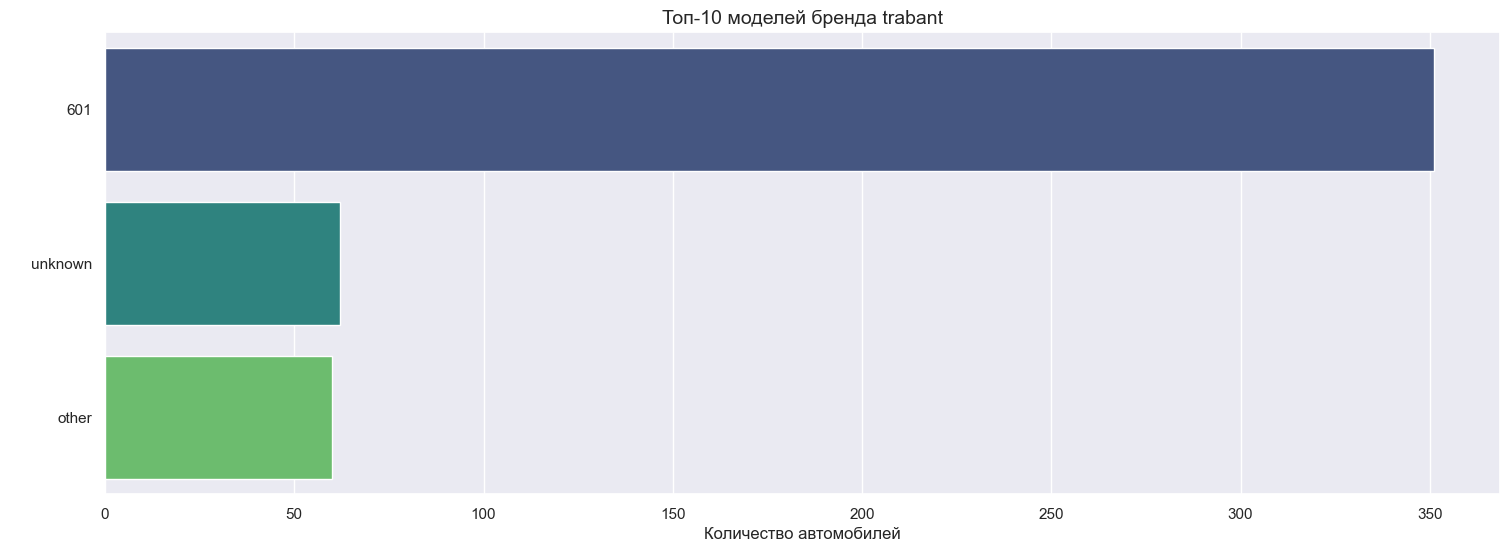

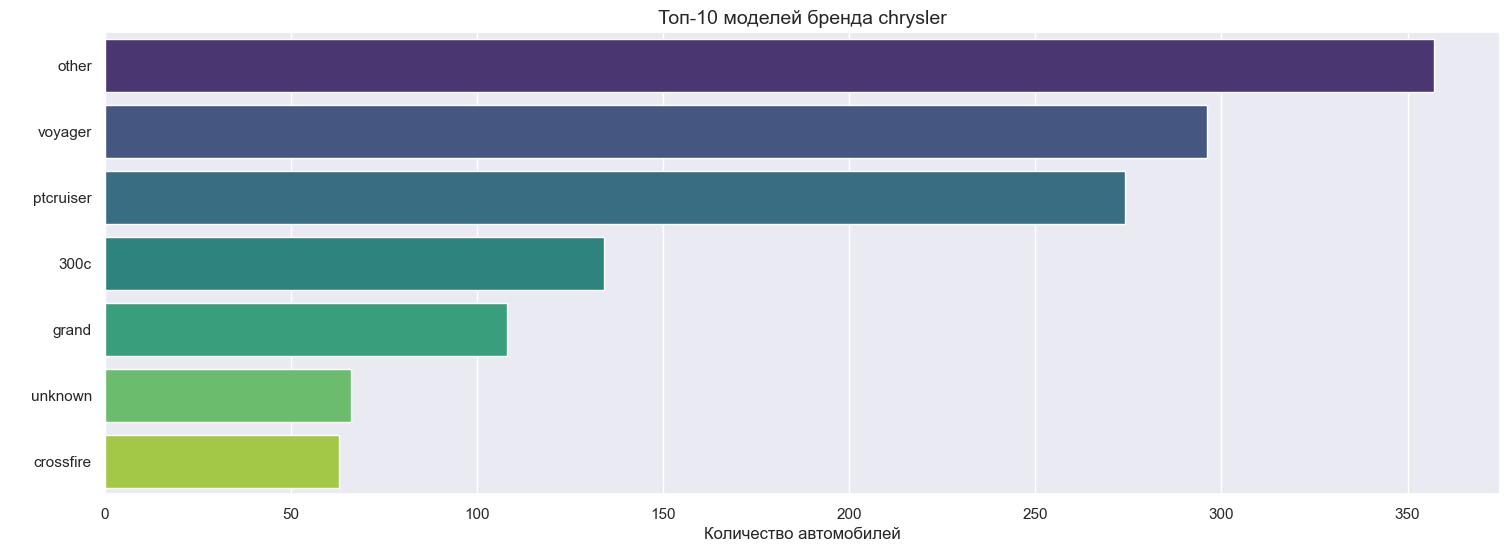

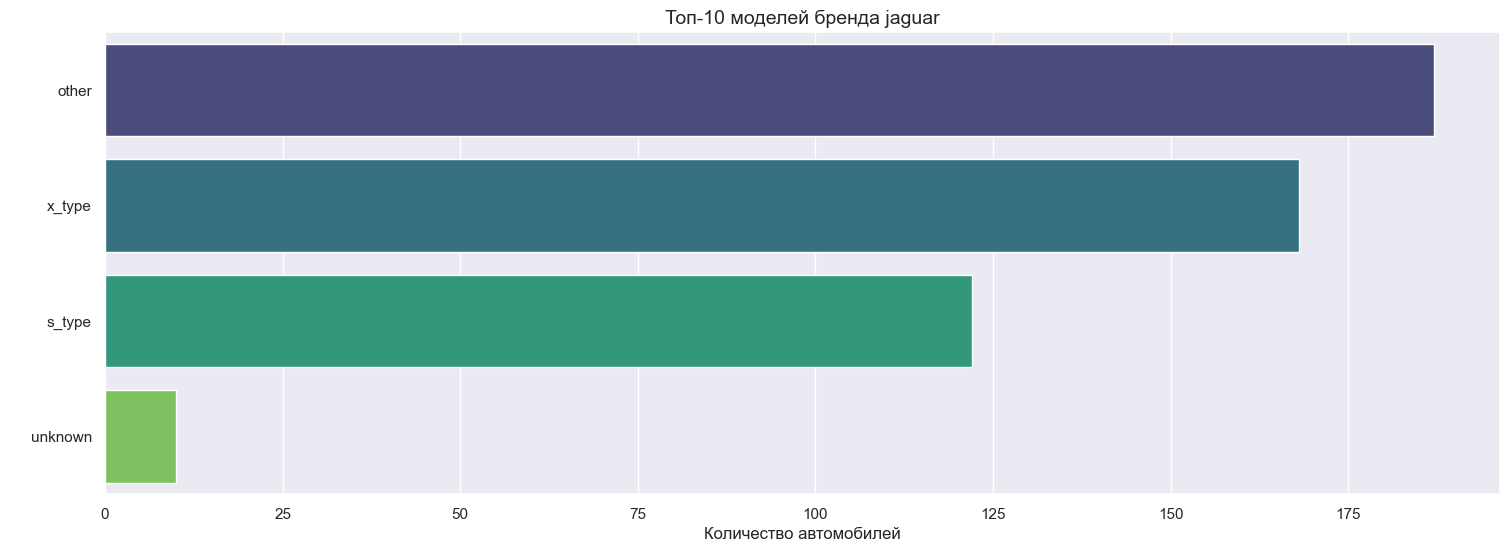

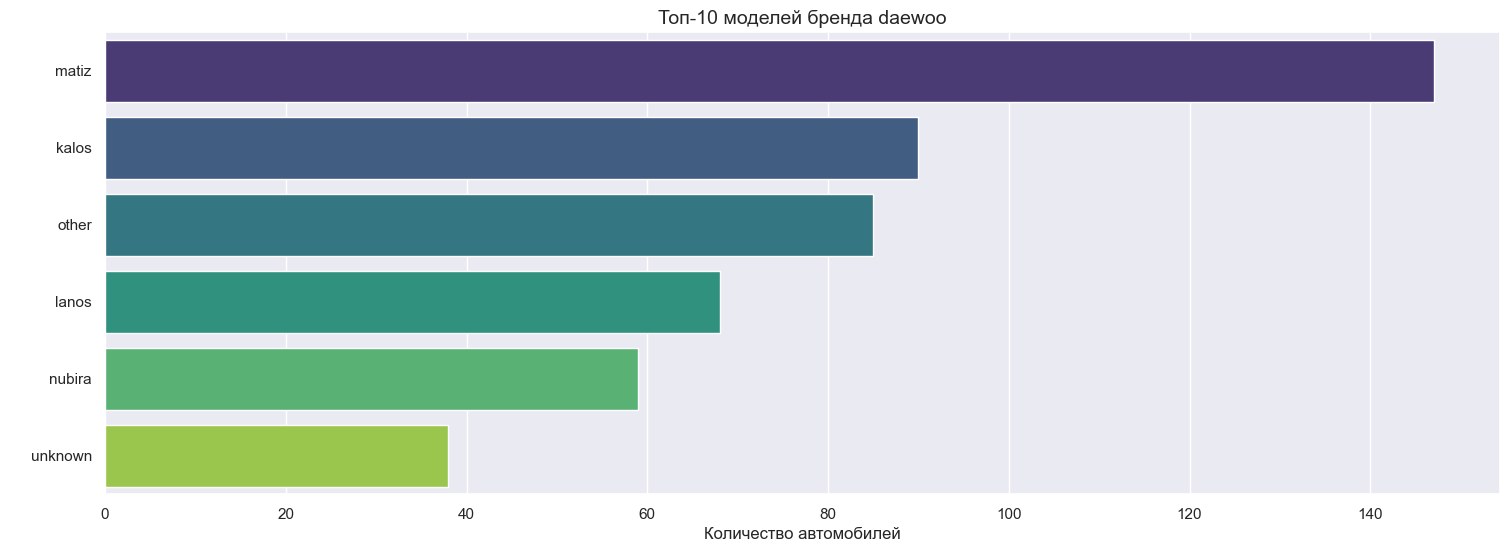

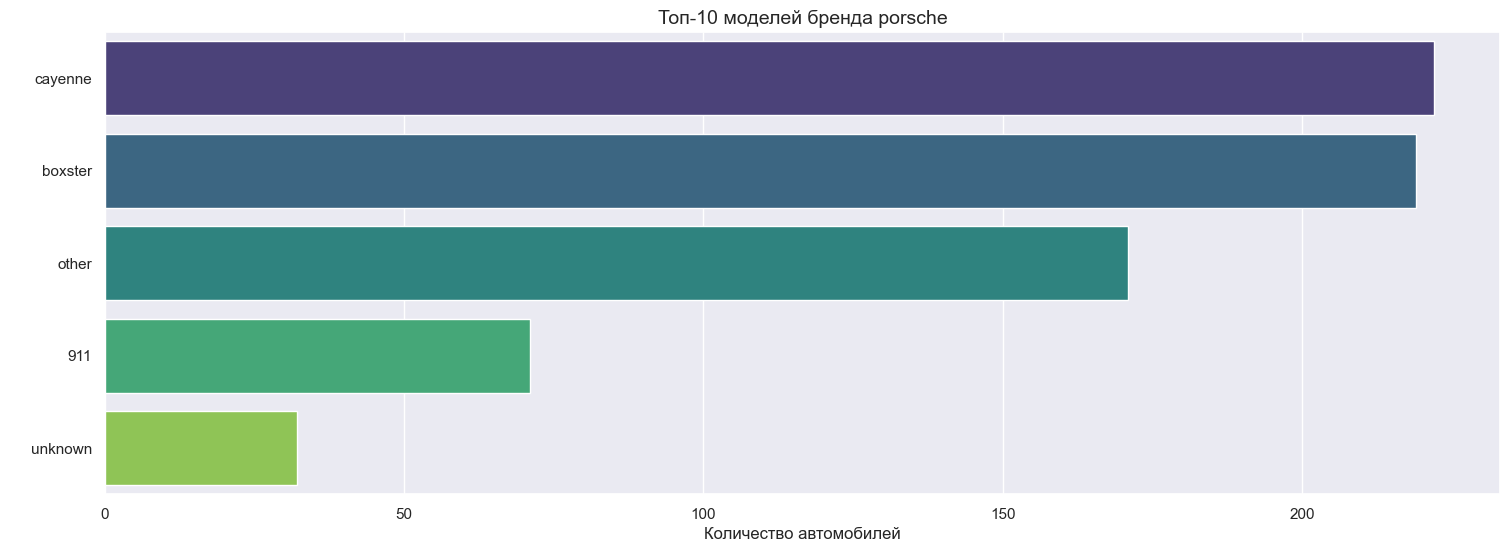

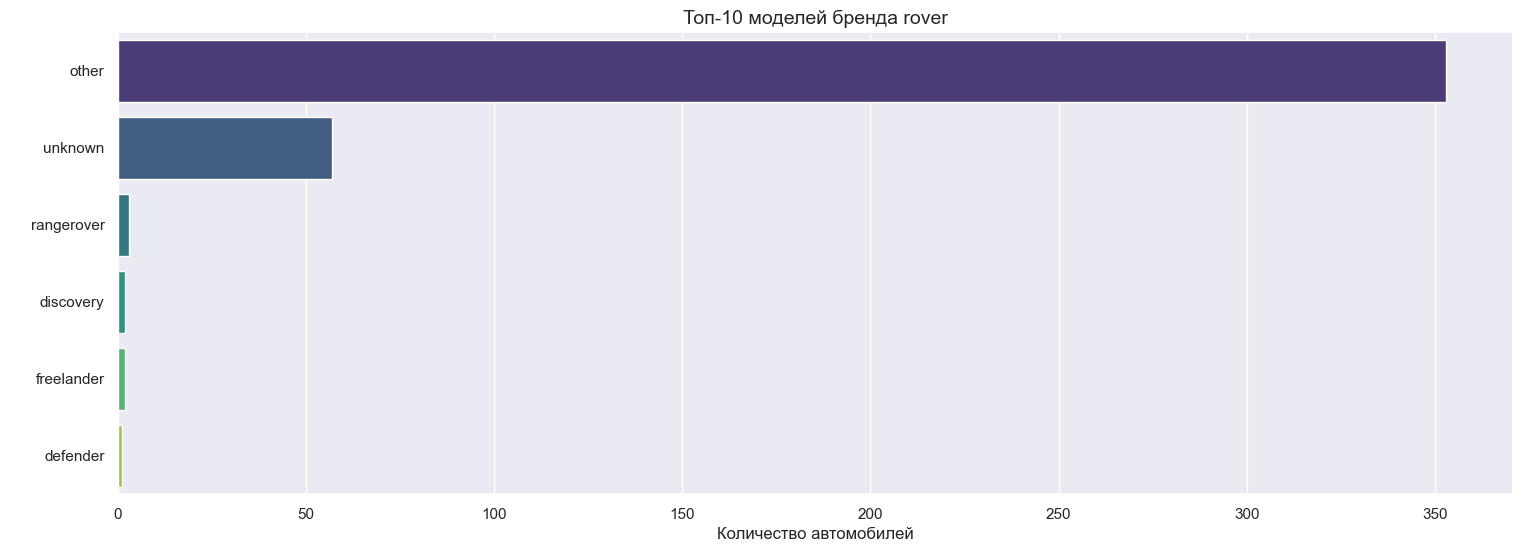

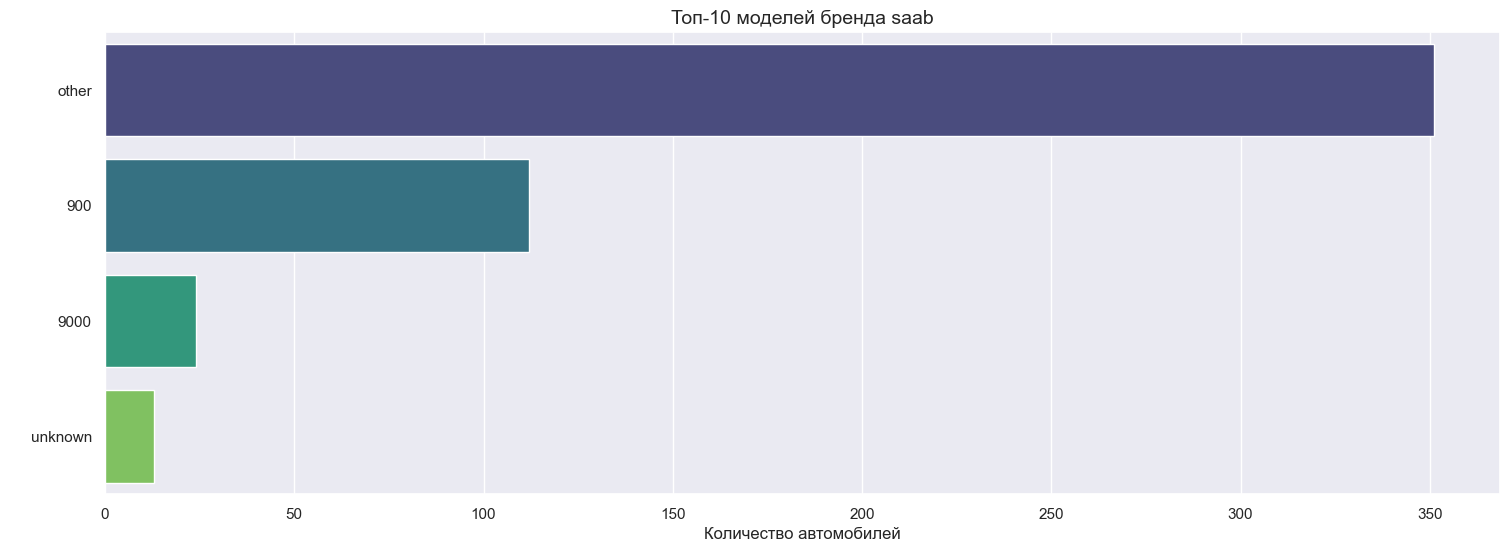

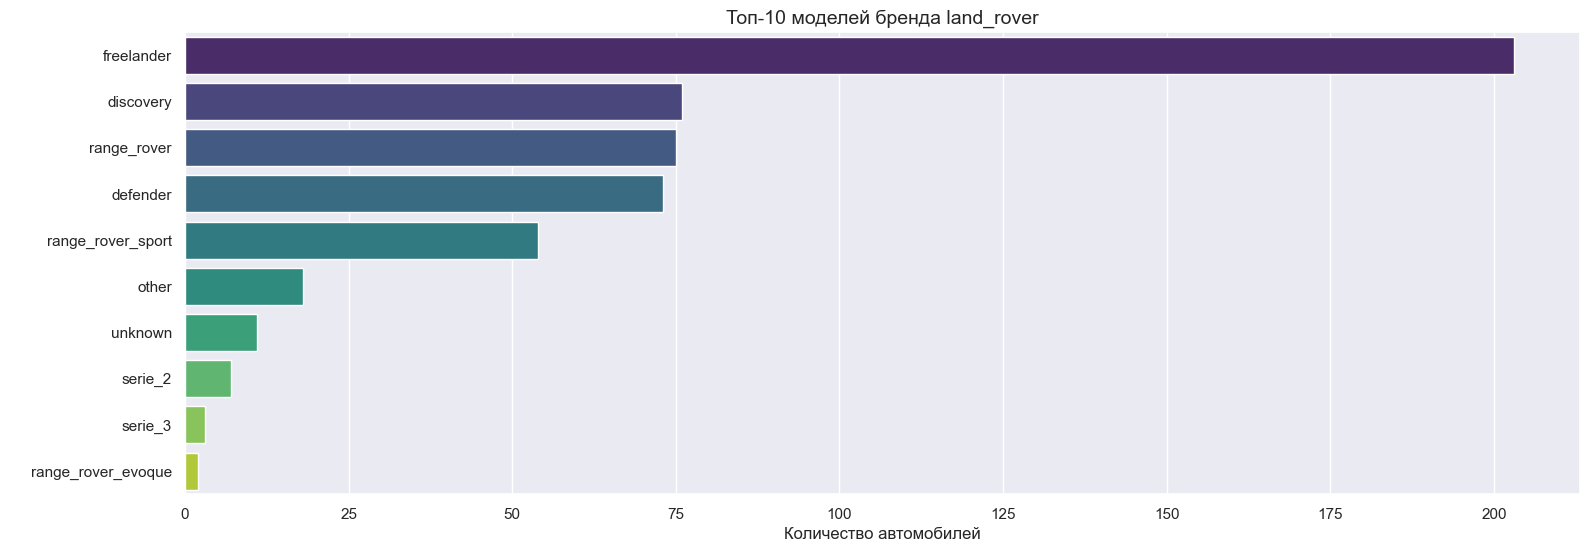

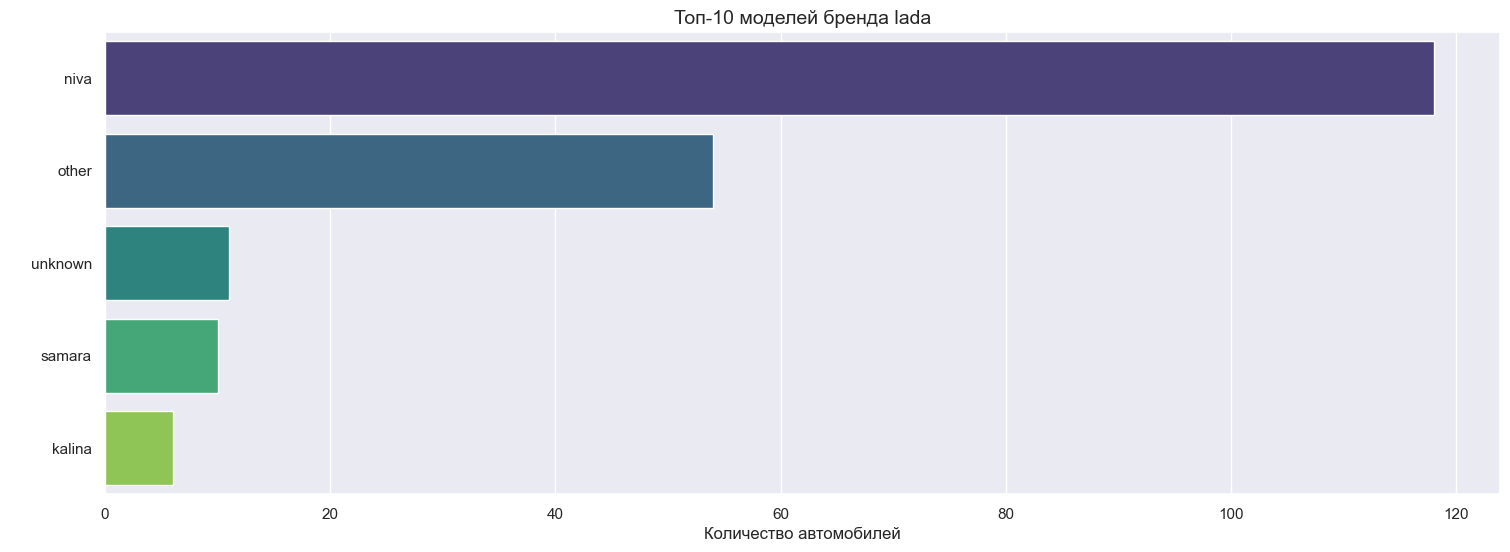

In [44]:
model_counts = autos_data.groupby(['brand', 'model']).size().reset_index(name='count')
all_brands = autos_data['brand'].unique()

for brand in all_brands:
    brand_models = model_counts[model_counts['brand'] == brand]
    top_10_models = brand_models.sort_values('count', ascending=False).head(10)
    if len(top_10_models) > 0:
        plt.figure(figsize=(18, 6))
        
        ax = sns.barplot(
            data=top_10_models,
            y='model',
            x='count',
            palette='viridis',
            hue='model',  # Для цветового разделения
            legend=False  # Убираем легенду
        )
        plt.title(f'Топ-10 моделей бренда {brand}', fontsize=14)
        plt.xlabel('Количество автомобилей', fontsize=12)
        plt.ylabel(' ')
        plt.show()

### Выводы

`vehicle_type` : топ 3 по типу кузова: sedan, small, wagon  
`gearbox` : больше маших на механике, чем с автоматической коробкой передач  
`model` : не особо информативный график, рассмотрим ниже топ 10 для каждого бренда  
`fuel_type` : больше всего машин с типом топлива petrol 
`brand` : самый популярный бренд - volkswagen (характеризует базу, а не рынок в целом)  
`repaired` : были в ремонте около 40000 машин

В целом данные выглядят типично для автомобильного рынка. Особенностей не наблюдаю.

Распределение моделей по брендам так же не выявило никаких особенностей, кроме как, что для бренда `sonstige _autos` - отсутствуют данные по моделям.

### Корреляционный анализ

In [45]:
def corr_matrix(data, interval_cols):
    corr_matrix = data.phik_matrix(interval_cols=interval_cols)
    plt.figure(figsize=(16, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='GnBu')
    plt.title('Матрица корреляции')
    plt.show()
    return

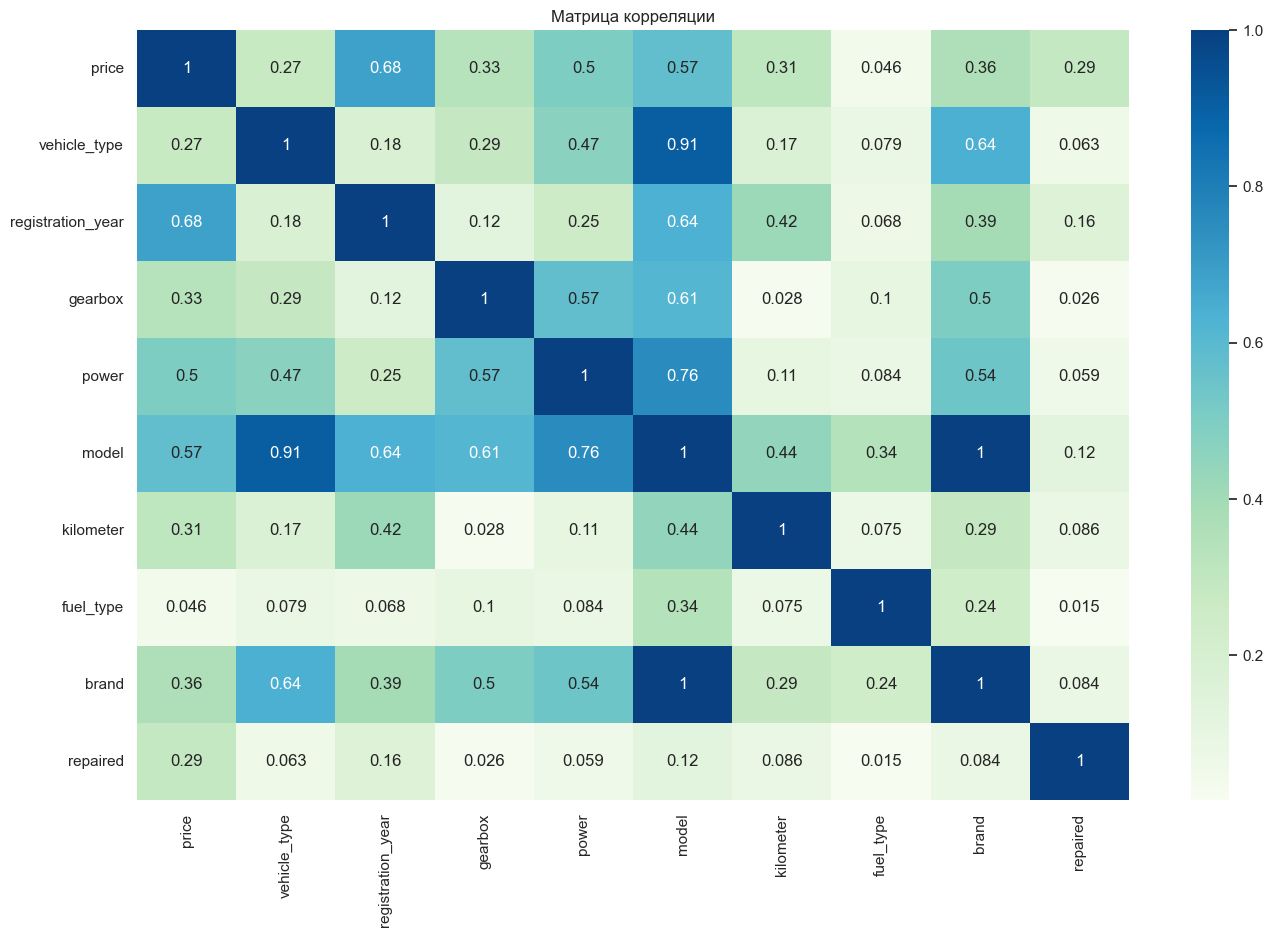

In [46]:
interval_cols = ['price','power']
corr_matrix(autos_data,num_features_col)

Наблюдается высокая корреляция между признаками brand и model. Дропаем brand для ускорения обучения

In [47]:
autos_data = autos_data.drop(columns='brand')

### Выводы

Цена автомобиля наиболее сильно коррелирует с:  

- Годом регистрации (0.63) — более новые автомобили стоят дороже.  
- Моделью (0.57) и мощностью (0.50) — более мощные и современные модели имеют более высокую цену.  
- Тип кузова (vehicle_type) очень сильно связан с моделью (0.90), что говорит о том, что определённые модели выпускаются в основном в конкретных типах кузова.  

Модель сильно коррелирует с:  

- Коробкой передач (0.61)  
- Мощностью (0.75)  
- Типом кузова (0.90)  

Слабая корреляция наблюдается между:  

- Типом топлива и другими параметрами (в среднем 0.1–0.3)  
- Ремонтом (repairer) и другими признаками (корреляции близки к 0)  
- Пробегом (kilometer) и ценой (0.31) — пробег слабо влияет на цену в данном наборе данных.  
- Год регистрации также умеренно коррелирует с мощностью (0.25) и моделью (0.61), что логично: новые модели чаще имеют более высокие характеристики.   

На цену автомобиля в наибольшей степени влияют год регистрации, модель и мощность. Тип кузова тесно связан с моделью, что может указывать на специфику модельного ряда. Пробег, тип топлива и наличие ремонта практически не влияют на цену в данном наборе данных.

## Машинное обучение
### Подготовка данных

In [50]:
cat_col = ['vehicle_type', 'gearbox','model', 'fuel_type', 'repaired','kilometer']
num_col = ['registration_year','power']

X = autos_data.drop(columns=['price'])
y = autos_data['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)


# Удаление лишних переменных перед обучением
del unique
del viz_num_features
del vis_cat_features
del corr_matrix
del uninformative_feature

# Очистка памяти от временных объектов
import gc
gc.collect()

76878

### LinearRegression

In [51]:
pipeline_lr = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', StandardScaler(), num_col),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_col)
    ])),
    ('model', LinearRegression(n_jobs=-1))
])

model_lr = pipeline_lr.fit(X_train,y_train)

### DecisionTreeRegressor

In [52]:
pipeline_dtr = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('ohe', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=UNKNOWN_CATEGORY), cat_col)
    ])),
    ('model', DecisionTreeRegressor(
        random_state=RANDOM_STATE,
    ))
])

hyperparams_dtr ={
    'model__max_depth': range(2, 21),
    'model__min_samples_split': range(2, 21),
    'model__max_features': range(2, 21),
 }


r_search_dtr = RandomizedSearchCV(
    pipeline_dtr, 
    hyperparams_dtr,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_dtr = r_search_dtr.fit(X_train, y_train)
print("Параметры лучшей модели:")
print(r_search_dtr.best_params_)

best_model_dtr = r_search_dtr.best_estimator_

Параметры лучшей модели:
{'model__min_samples_split': 16, 'model__max_features': 8, 'model__max_depth': 19}


### CatBoostRegressor

In [53]:
model_cbr = CatBoostRegressor(
    random_state=RANDOM_STATE,
    verbose=False,
    cat_features=cat_col,
)

hyperparams_cbr = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5],  # Уменьшить количество
    'iterations': [5, 10, 15, 20],  # Более крупный шаг
    'depth': [4, 6, 8, 10, 12]  
}

r_search_cbr = RandomizedSearchCV(
    estimator=model_cbr,
    param_distributions=hyperparams_cbr,
    n_iter=10,  
    cv=5, 
    scoring='neg_mean_squared_error',  
    n_jobs=-1,  
    random_state=RANDOM_STATE
)

model_cbr = r_search_cbr.fit(X_train, y_train)
print("Параметры лучшей модели:")
print(r_search_cbr.best_params_)

best_model_cbr = r_search_cbr.best_estimator_


Параметры лучшей модели:
{'learning_rate': 0.5, 'iterations': 15, 'depth': 10}


### LightGBM

In [54]:
X_train_lgbm = X_train.copy()
X_test_lgbm = X_test.copy()

# Преобразование категориальных признаков в тип данных 'category'
for col in cat_col:
    X_train_lgbm[col] = X_train_lgbm[col].astype('category')
    X_test_lgbm[col] = X_test_lgbm[col].astype('category')

model_lgbm = LGBMRegressor(
    learning_rate=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    reg_lambda=0.1,
    min_child_samples=5,
    min_child_weight=1,
    # categorical_feature=cat_col
)

# Гиперпараметры для поиска
hyperparams_lgbm = {
    'num_leaves': [50, 100],
    'max_depth': [5, 10]
}

r_search_lgbm = RandomizedSearchCV(
    model_lgbm,
    hyperparams_lgbm,
    n_iter=5,  
    cv=3, 
    scoring='neg_mean_squared_error',  
    n_jobs=-1,  
    random_state=RANDOM_STATE
)

model_lgbm  = r_search_lgbm.fit(X_train_lgbm, y_train, categorical_feature=cat_col)

print("Параметры лучшей модели:")
print(r_search_lgbm.best_params_)

best_model_lgbm  = r_search_lgbm.best_estimator_



Параметры лучшей модели:
{'num_leaves': 100, 'max_depth': 10}


### Обучение и выбор лучшей модели

In [55]:
models ={
    "Линейная регрессия":pipeline_lr,
    "DecisionTreeRegressor":best_model_dtr,
    "CatBoostRegressor":best_model_cbr,
    "LightGBM":best_model_lgbm
}

In [56]:
def measure_time(func):
    start = time.time()
    result = func()
    end = time.time()
    return result, (end - start) / 60 

results = []

In [57]:
for name, model in models.items():
    X_data = X_train_lgbm if name == "LightGBM" else X_train
    
    _, train_time = measure_time(lambda: model.fit(X_data, y_train))
    _, pred_time = measure_time(lambda: model.predict(X_data))
    
    rmse = (-cross_val_score(
        model,
        X_data, 
        y_train, 
        cv=5, 
        scoring='neg_mean_squared_error'
    ).mean()) ** 0.5

    results.append({
        'model_name': name,
        'train_time': train_time,
        'pred_time': pred_time,
        'RMSE': rmse
    })
results_df = pd.DataFrame(results)

In [58]:
def calculate_score(row, df):
    min_rmse = df['RMSE'].min()
    min_train = df['train_time'].min()
    min_pred = df['pred_time'].min()
    return ((row['RMSE'] / min_rmse)*0.6 + 
            (row['train_time'] / min_train)*0.2 + 
            (row['pred_time'] / min_pred))*0.2 / 3

In [59]:
results_df['score'] = results_df.apply(lambda row: calculate_score(row, results_df), axis=1)

In [60]:
results_df.sort_values('score')

,model_name,train_time,pred_time,RMSE,score
3,LightGBM,0.015416,0.005521,1642.203777,0.151026
2,CatBoostRegressor,0.016890,0.005126,1845.740112,0.152159
1,DecisionTreeRegressor,0.008319,0.004264,3088.372756,0.155225
0,Линейная регрессия,0.056939,0.006250,2634.955398,0.253148


In [61]:
results_df=results_df[results_df['RMSE']<2500].sort_values('score')

### Качество модели на тестовой выборке

In [62]:
predictions, test_time = measure_time(lambda: best_model_lgbm.predict(X_test_lgbm))
final_rmse_test = mean_squared_error(y_test, predictions) ** 0.5

In [63]:
best_model = results_df.iloc[0]

print(
    f"""
Лучшая модель: {best_model['model_name']}
{'-'*50}
Параметры лучшей модели: {r_search_lgbm.best_params_}
Score: {best_model['score']:.4f}
RMSE на тренировочных данных: {best_model['RMSE']:.2f}
Время обучения: {best_model['train_time']:.3f} сек
Время предсказания на тренировочных данных: {best_model['pred_time']:.3f} сек
{'-'*50}
RMSE на тестовых данных: {final_rmse_test:.2f}
Время предсказания на тестовых данных: {test_time:.3f} сек
"""
)


Лучшая модель: LightGBM
--------------------------------------------------
Параметры лучшей модели: {'num_leaves': 100, 'max_depth': 10}
Score: 0.1510
RMSE на тренировочных данных: 1642.20
Время обучения: 0.015 сек
Время предсказания на тренировочных данных: 0.006 сек
--------------------------------------------------
RMSE на тестовых данных: 1632.01
Время предсказания на тестовых данных: 0.002 сек



### Проверка важности признаков

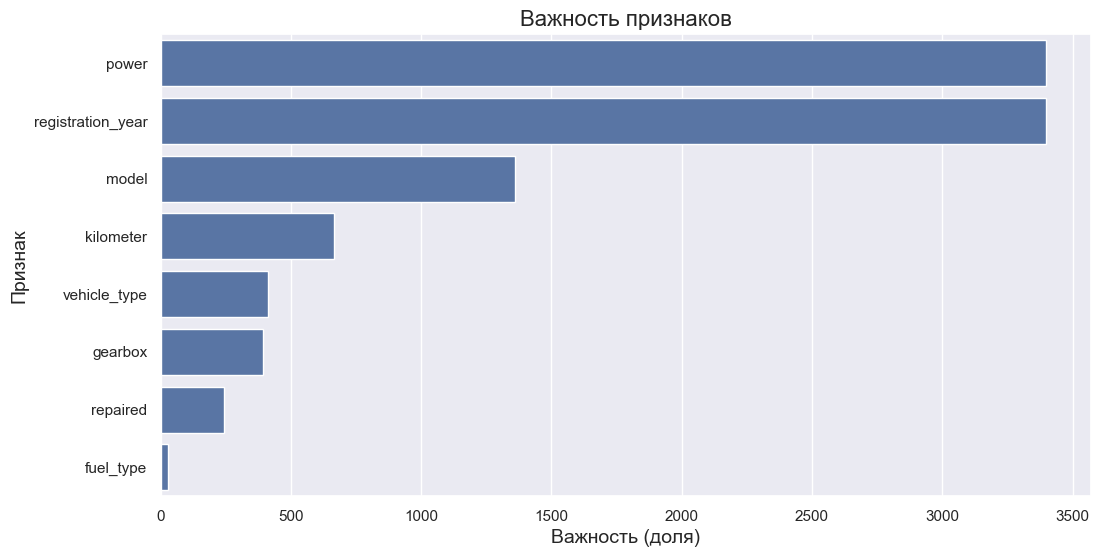

In [64]:
feature_importances = pd.DataFrame(
    {
        'Feature': X_test_lgbm.columns.tolist(),
        'Importance': best_model_lgbm.feature_importances_
    })
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
feature_importances
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data = feature_importances,
    y = 'Feature',
    x = 'Importance'
)
ax.set_title('Важность признаков', fontsize=16)
ax.set_xlabel('Важность (доля)', fontsize=14)
ax.set_ylabel('Признак', fontsize=14)
plt.show()

Модель сфокусирована на технических характеристиках автомобиля (мощность, дата регистрации, пробег) и практически игнорирует такие категориальные признаки, как тип топлива. Это может быть как следствием несбалансированности классов.

## Итоги

Разработана модель машинного обучения для предсказания рыночной стоимости автомобилей с пробегом для сервиса **«Не бит, не крашен»**.  
Цель — внедрить модель в мобильное приложение для быстрой оценки стоимости автомобилей, что поможет привлечь новых клиентов.

---

<font size="5">Предсказание стоимости автомобилей</font>

**Лучшая модель:** `LightGBM` с подобранными гиперпараметрами.

**Параметры лучшей модели:**
- `num_leaves`: 100
- `max_depth`: 10

**Метрики модели:**
- RMSE на тренировочных данных: **1642.20 €**
- RMSE на тестовых данных: **1632.01 €**
- Время обучения: **0.008 секунды**
- Время предсказания: **0.005 секунды**
- Время предсказания на тестовых данных: **0.002 секунды**

**Ключевые признаки, влияющие на цену:**
1. **Год регистрации** — самый сильный фактор (корреляция с ценой: `0.63`).
2. **Модель автомобиля** — второй по значимости признак.
3. **Мощность (л.с.)** — также сильно влияет на стоимость.

**Выводы по модели:**
- Модель демонстрирует хорошее качество предсказания (RMSE ~ 1800–1900 €).
- Обучение и предсказание происходят быстро, что удовлетворяет требованиям заказчика.
- Модель интерпретируема, что позволяет объяснять прогнозы пользователям.

---

<font size="5">Корреляционный анализ и ключевые зависимости</font>
- **Тип кузова** тесно связан с моделью (корреляция `0.90`), что отражает специфику модельных рядов.
- **Пробег** слабо коррелирует с ценой (`0.31`), что говорит о его меньшей значимости в данном наборе данных.
- **Наличие ремонта** и **тип топлива** практически не влияют на цену.

---

<font size="5">Портрет дорогого автомобиля (на основе исследовательского данных)</font>
- **Год регистрации:** после 2010 года.
- **Мощность:** выше 150 л.с.
- **Модель:** современные и премиальные модели (например, BMW 5er, Audi A4, Mercedes E-Klasse).
- **Тип кузова:** sedan, SUV, coupe.
- **Пробег:** до 100 000 км.
- **Коробка передач:** автоматическая.

---

<font size="5">Подтверждённые гипотезы</font>
1. **Новые автомобили стоят дороже** — год регистрации имеет наибольшую корреляцию с ценой.
2. **Модель и мощность — ключевые факторы цены**, что отражает рыночный спрос на определённые марки и характеристики.
3. **Пробег не является решающим фактором** при наличии других характеристик.

---

<font size="5">Рекомендации для бизнеса</font>

**Для улучшения модели и сервиса:**
- Регулярно обновлять данные о ценах и характеристиках автомобилей.
- Добавить признаки: цвет автомобиля, состояние салона, наличие дополнительного оборудования.


<font size="5">Заключение</font>  
Модель на основе `LightGBM` удовлетворяет всем критериям заказчика:

- **Качество предсказания:** RMSE в пределах допустимой погрешности для рынка.
- **Скорость работы:** обучение и предсказание занимают менее секунды.
- **Интерпретируемость:** можно объяснять прогнозы пользователям.

**Внедрение модели в приложение позволит:**
- Упростить процесс оценки автомобиля.
- Повысить вовлечённость пользователей.
- Увеличить конверсию в заявки на продажу.

---

**Готово к внедрению.**  
Модель соответствует требованиям бизнеса и готова к интеграции в приложение «Не бит, не крашен».